# Analítica Comercial

**Objetivo:** Ayudar a los especialistas en marketing a reducir costos eliminando fuentes de tráfico no rentables y redistribuyendo el presupuesto.

**Datos:** Tenemos datos de Yandex.Afisha desde junio de 2017 hasta finales de mayo de 2018:

- log del servidor con datos sobre visitas al sitio web de Yandex.Afisha,
- descarga de todos los pedidos para este período,
- estadísticas de gastos publicitarios.

**Tareas:**

Analizar cómo los clientes usan el servicio,

cuándo hacen sus primeras compras en el sitio,

cuánto dinero trae cada cliente a la empresa,

cuándo se recupera el costo de atraer a un cliente.

Nota: Los ingresos se miden en unidades convencionales - u.c.

## Preprocesamiento

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np    
import seaborn as sns
pd.set_option('display.max_columns', None)

In [2]:
visits  = pd.read_csv('https://code.s3.yandex.net/datasets/visits_log.csv')
costs = pd.read_csv('https://code.s3.yandex.net/datasets/costs.csv')
orders = pd.read_csv('https://code.s3.yandex.net/datasets/orders_log.csv')

# visits  = pd.read_csv('visits_log_us.csv')
# costs = pd.read_csv('costs_us.csv')
# orders = pd.read_csv('orders_log_us.csv')

In [3]:
def first_look (df):
  print ('------------- primeras 5 filas ------------')
  (df.head())
  print('')
  print('')
  print ('------------- tipos de datos ------------')
  print (df.info())
  print('')
  print('')
  print ('------------- valores faltantes ------------')
  count = 0
  for element in df.columns:
    if df[element].isna().sum() > 0: 
      print(element, ' - ', df[element].isna().sum(), 'valores faltantes')
      count = +1
  if count == 0:
    print('Sin valores faltantes')
  print('')
  print('')
  print ('------------- Duplicados ------------')
  if df.duplicated().sum() > 0:
    print('Duplicados: ', df.duplicated().sum())
  else:
    print('Sin duplicados')

### Visitas

In [4]:
first_look(visits)

------------- primeras 5 filas ------------


------------- tipos de datos ------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB
None


------------- valores faltantes ------------
Sin valores faltantes


------------- Duplicados ------------
Sin duplicados


No hay valores faltantes ni duplicados.

Necesitamos renombrar las columnas.

Necesitamos cambiar los tipos de datos en las columnas de fecha.

Sería bueno evaluar cuántas fuentes y tipos de dispositivos tenemos y cómo se distribuyen los datos entre ellos.

Sería bueno ver las fechas mínimas y máximas en el conjunto de datos.

In [5]:
#cambiar tipos
visits['Start Ts'] = pd.to_datetime(visits['Start Ts'], format="%Y-%m-%d %H:%M:%S")
visits['End Ts'] = pd.to_datetime(visits['End Ts'], format="%Y-%m-%d %H:%M:%S")

#renombrar columnas
visits = visits.rename(columns={"Device": "device", "End Ts": "session_end_ts", "Source Id": "source_id", "Start Ts": "session_start_ts", "Uid": "uid"})

#verificar
visits.head()

,device,session_end_ts,source_id,session_start_ts,uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168


##### opción

In [6]:
#verificar dispositivos
visits.value_counts('device')

device
desktop    262567
touch       96833
Name: count, dtype: int64

Podemos cambiar la columna al tipo categoría, porque solo tenemos 2 tipos de dispositivos.

Más visitas provienen de PC que de dispositivos móviles.

In [7]:
# verificar fuentes
visits.value_counts('source_id')

source_id
4     101794
3      85610
5      66905
2      47626
1      34121
9      13277
10     10025
7         36
6          6
Name: count, dtype: int64

Solo había 10 fuentes.

De la 8ª fuente, no llegaron usuarios en absoluto (¿o decidieron abandonarla?).

De las fuentes 6 y 7, llegaron muy pocos usuarios. Muy probablemente, se excluirán del análisis posterior, o tendremos que eliminarlas.

In [8]:
#verificar fecha
visits['session_start_ts'].min(), visits['session_start_ts'].max(), visits['session_end_ts'].min(), visits['session_end_ts'].max()

(Timestamp('2017-06-01 00:01:00'),
 Timestamp('2018-05-31 23:59:00'),
 Timestamp('2017-06-01 00:02:00'),
 Timestamp('2018-06-01 01:26:00'))

Las fechas mínimas de inicio y fin de sesiones corresponden a la descripción de los datos.

La fecha máxima de inicio de sesión también coincide con las condiciones.

Pero la última sesión terminó después de mayo de 2017. Sería bueno ver cuántas de estas sesiones tenemos.

In [9]:
visits[visits['session_end_ts'] > '2018-06-01']

,device,session_end_ts,source_id,session_start_ts,uid
2330,desktop,2018-06-01 00:05:00,2,2018-05-31 23:30:00,5300693976971713685
43215,desktop,2018-06-01 00:13:00,4,2018-05-31 23:46:00,12296626599487328624
46667,desktop,2018-06-01 00:13:00,5,2018-05-31 23:48:00,1107134732939577311
154728,desktop,2018-06-01 00:09:00,2,2018-05-31 22:52:00,12484396335714047199
198329,desktop,2018-06-01 00:11:00,3,2018-05-31 23:59:00,3720373600909378583
216791,touch,2018-06-01 00:06:00,5,2018-05-31 23:45:00,9951896961656595558
263781,desktop,2018-06-01 00:25:00,1,2018-05-31 23:59:00,4906562732540547408
269213,touch,2018-06-01 00:12:00,10,2018-05-31 23:59:00,10723414689244282024
288563,touch,2018-06-01 00:01:00,4,2018-05-31 23:37:00,1094281763368510391
299620,desktop,2018-06-01 00:04:00,4,2018-05-31 23:59:00,83872787173869366


11 sesiones comenzaron en mayo de 2017 y terminaron en junio de 2018. Si se realizó una compra durante estas sesiones, ya se puede atribuir al intervalo de tiempo especificado en la tarea.

Podemos eliminar estas sesiones: representan menos del 1% de los datos. Pero, dado que los estudiantes rara vez hacen esto, y necesitamos números lo más cercanos posible a sus decisiones correctas, dejaremos estas filas.

##### fin opción

### Pedidos

In [10]:
first_look(orders)

------------- primeras 5 filas ------------


------------- tipos de datos ------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB
None


------------- valores faltantes ------------
Sin valores faltantes


------------- Duplicados ------------
Sin duplicados


El mismo trabajo aquí.

In [11]:
orders['Buy Ts'] = pd.to_datetime(orders['Buy Ts'])

orders = orders.rename(columns={"Buy Ts": "buy_ts", "Revenue": "revenue", "Uid": "uid"})

orders.head()

,buy_ts,revenue,uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450


### Costos

In [12]:
first_look(costs)

------------- primeras 5 filas ------------


------------- tipos de datos ------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB
None


------------- valores faltantes ------------
Sin valores faltantes


------------- Duplicados ------------
Sin duplicados


Lo mismo aquí.

In [13]:
costs['dt'] = pd.to_datetime(costs['dt'])
costs['dt'].min(), costs['dt'].max()

(Timestamp('2017-06-01 00:00:00'), Timestamp('2018-05-31 00:00:00'))

# Hacer informes y calcular métricas

## Producto

### ¿Cuántas personas lo usan cada día, semana y mes?

In [14]:
visits['session_month'] = visits['session_start_ts'].dt.month
visits['session_week']  = visits['session_start_ts'].dt.isocalendar().week
visits['session_date']  = visits['session_start_ts'].dt.date

visits.head()

,device,session_end_ts,source_id,session_start_ts,uid,session_month,session_week,session_date
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,12,51,2017-12-20
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2,8,2018-02-19
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,7,26,2017-07-01
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,5,20,2018-05-20
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,12,52,2017-12-27


In [15]:
dau = visits.groupby('session_date').agg({'uid': 'nunique'})
wau = visits.groupby('session_week').agg({'uid': 'nunique'})
mau = visits.groupby('session_month').agg({'uid': 'nunique'})

print('DAU:', int(dau.mean()), 'visitantes')
print('WAU:', int(wau.mean()), 'visitantes')
print('MAU:', int(mau.mean()), 'visitantes')

DAU: 907 visitantes
WAU: 5825 visitantes
MAU: 23228 visitantes


C:\Users\HG_Co\AppData\Local\Temp\ipykernel_40724\3601386677.py:5: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print('DAU:', int(dau.mean()), 'visitantes')
C:\Users\HG_Co\AppData\Local\Temp\ipykernel_40724\3601386677.py:6: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print('WAU:', int(wau.mean()), 'visitantes')
C:\Users\HG_Co\AppData\Local\Temp\ipykernel_40724\3601386677.py:7: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print('MAU:', int(mau.mean()), 'visitantes')


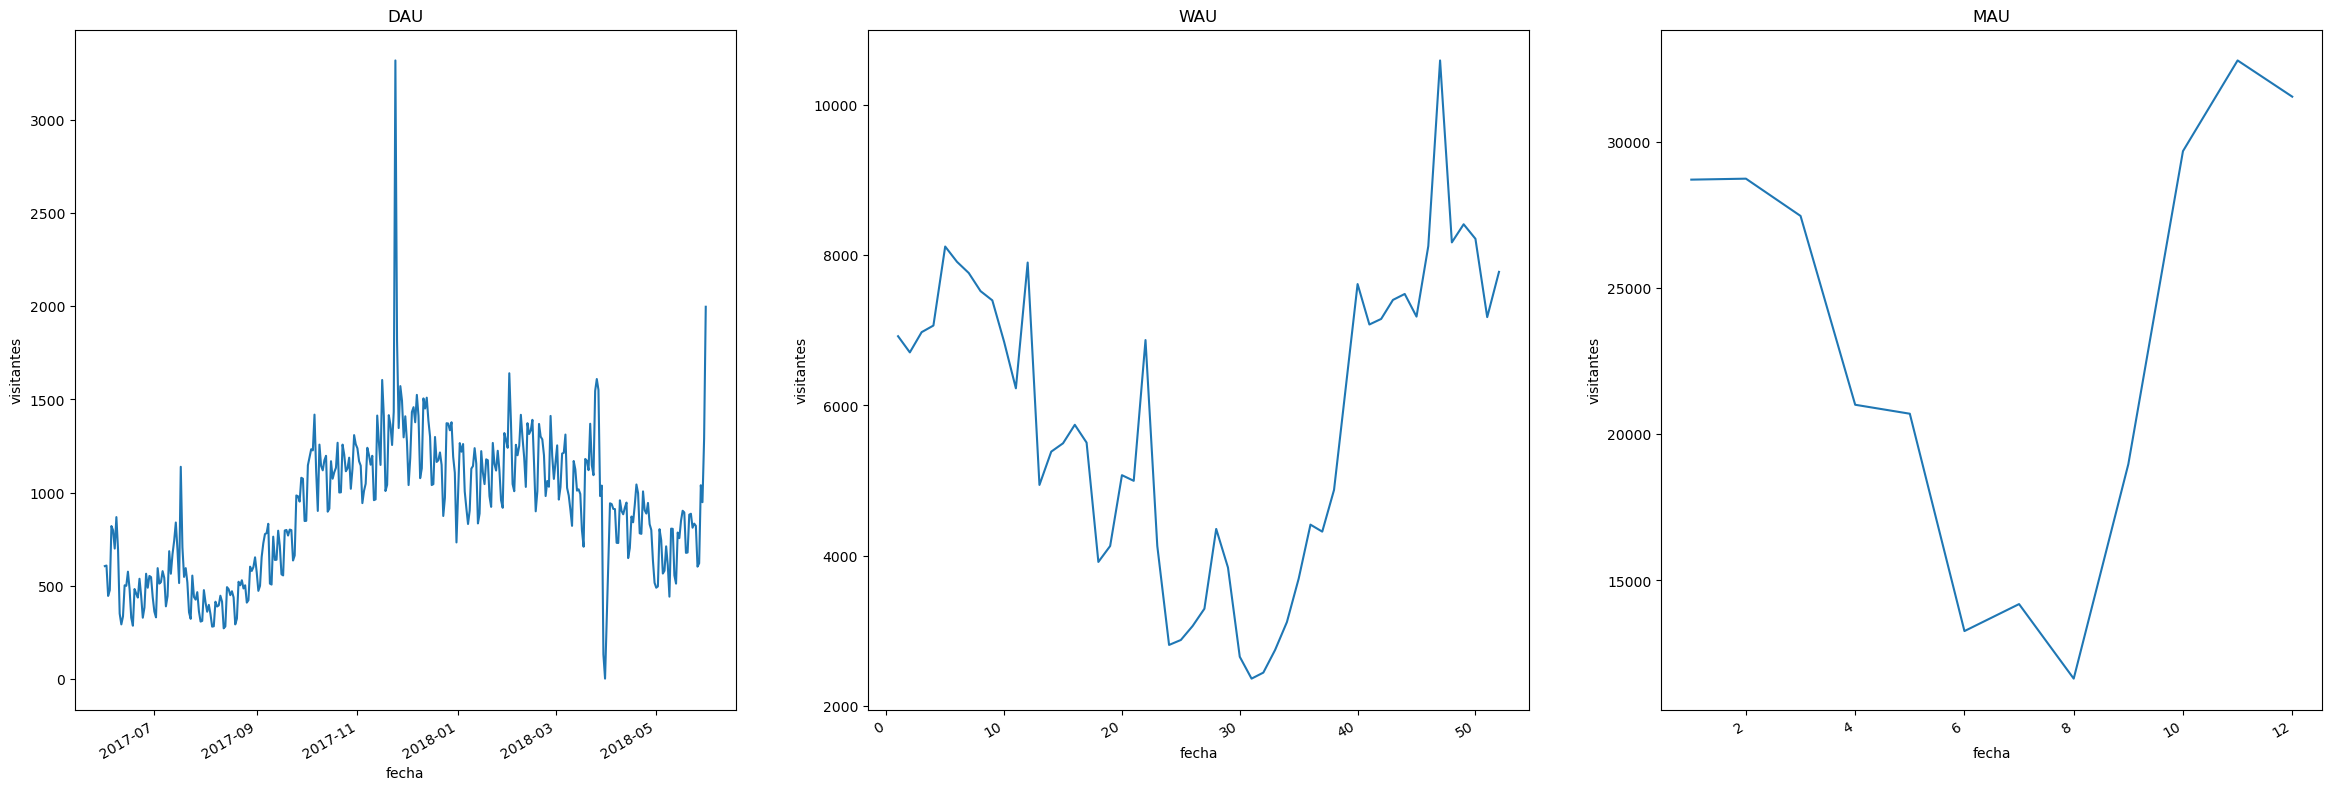

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(29, 10))
ax[0].plot(dau)
ax[0].set(title = 'DAU', xlabel = 'fecha', ylabel = 'visitantes')
ax[1].plot(wau)
ax[1].set(title = 'WAU', xlabel = 'fecha', ylabel = 'visitantes')
ax[2].plot(mau)
ax[2].set(title = 'MAU', xlabel = 'fecha', ylabel = 'visitantes')
fig.autofmt_xdate(rotation=30)
plt.show()

### ¿Cuántas sesiones hay por día? (Un usuario puede tener más de una sesión.)

In [17]:
sess_per_user = visits.groupby('session_date').agg({'uid': ['count','nunique']})
sess_per_user.columns = ['n_sessions', 'n_users']
sess_per_user['sess_per_user'] = sess_per_user['n_sessions'] / sess_per_user['n_users']
sess_per_user.head()

,n_sessions,n_users,sess_per_user
session_date,,,
2017-06-01,664,605,1.097521
2017-06-02,658,608,1.082237
2017-06-03,477,445,1.071910
2017-06-04,510,476,1.071429
2017-06-05,893,820,1.089024


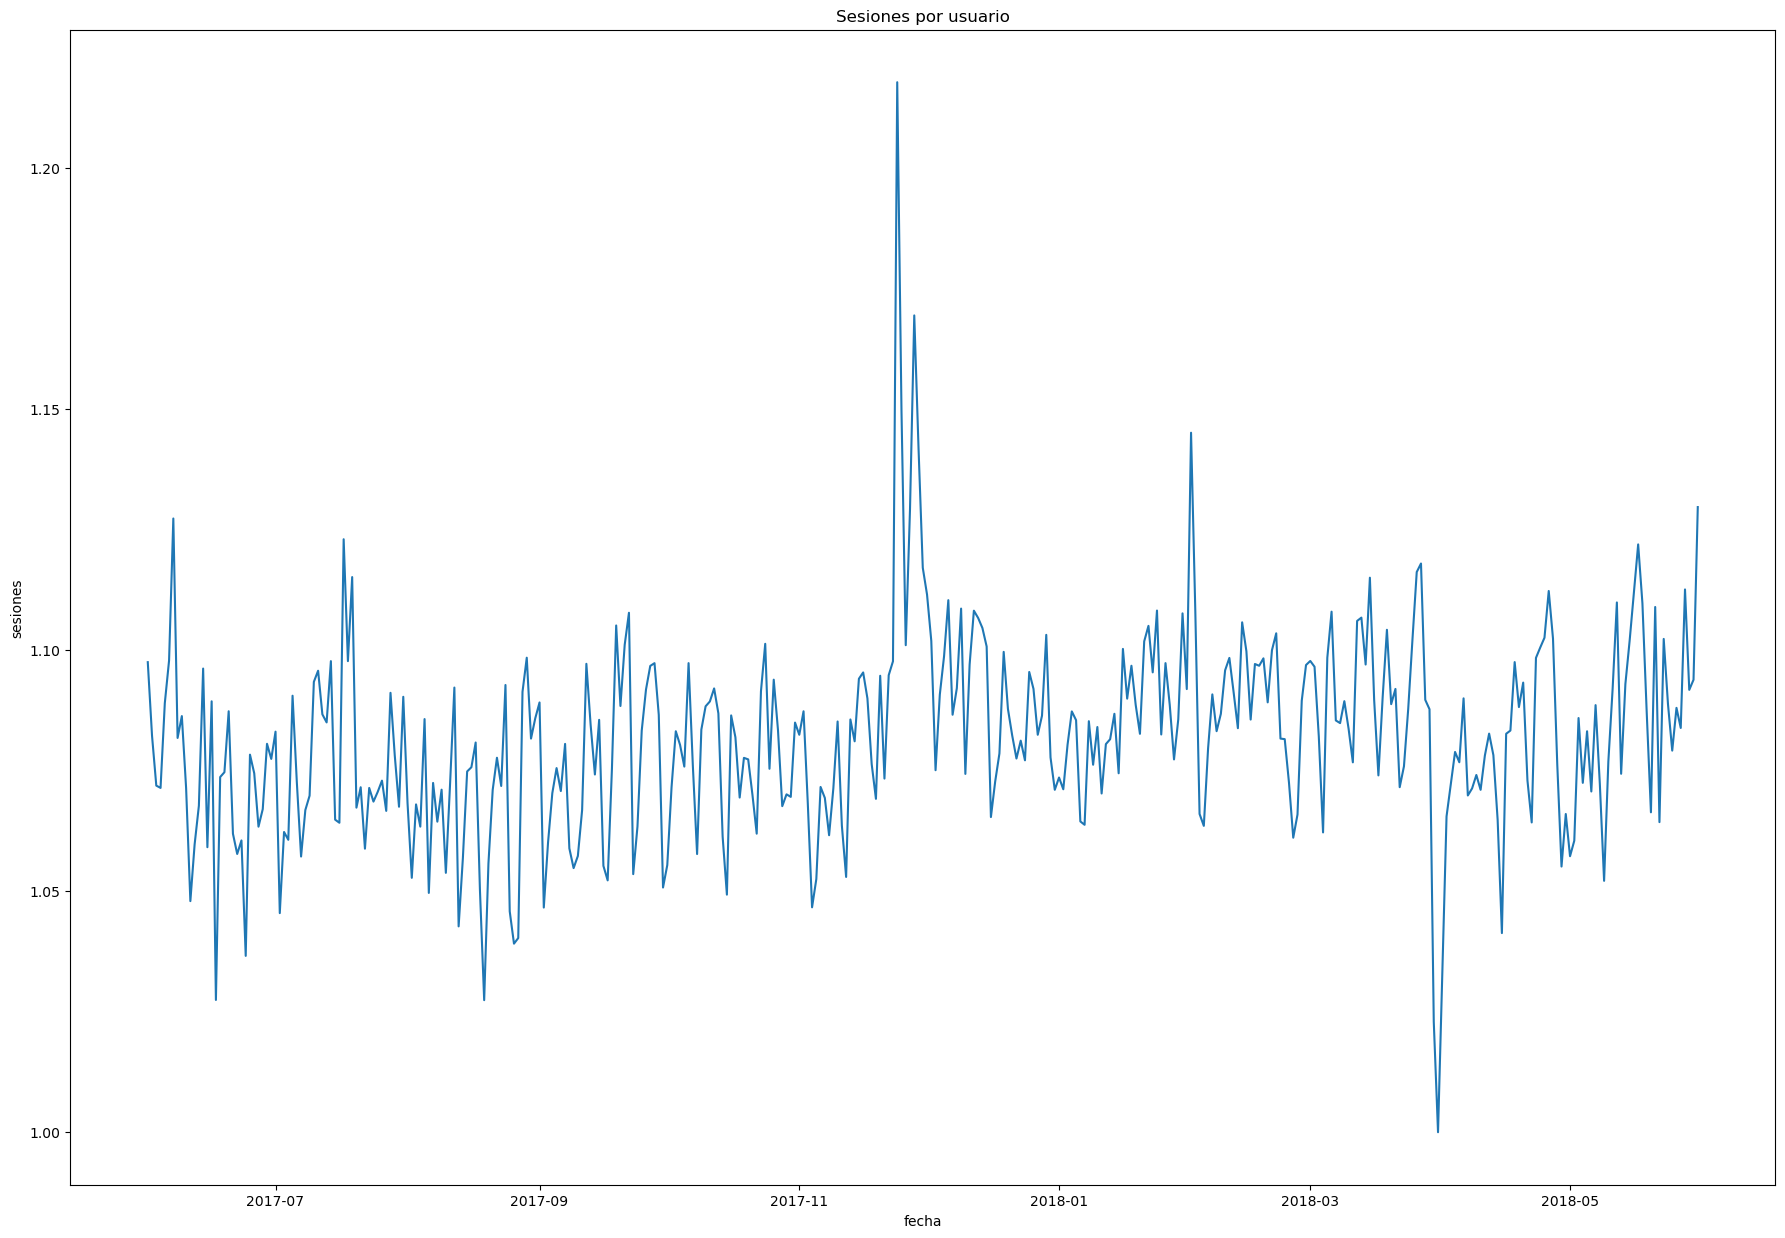

In [18]:
plt.figure(figsize= (22,15))
sess_per_user['sess_per_user'].plot().set(title = 'Sesiones por usuario', xlabel = 'fecha', ylabel = 'sesiones');

In [19]:
print('El promedio de sesiones por usuario es {} por día.'.format(round(sess_per_user['sess_per_user'].mean(),2)))

El promedio de sesiones por usuario es 1.08 por día.


### ¿Cuál es la duración de cada sesión?

In [20]:
visits['session_duration_sec'] = (visits['session_end_ts'] - visits['session_start_ts']).dt.seconds
visits['session_duration_sec'].describe()

count    359400.000000
mean        643.506489
std        1016.334786
min           0.000000
25%         120.000000
50%         300.000000
75%         840.000000
max       84480.000000
Name: session_duration_sec, dtype: float64

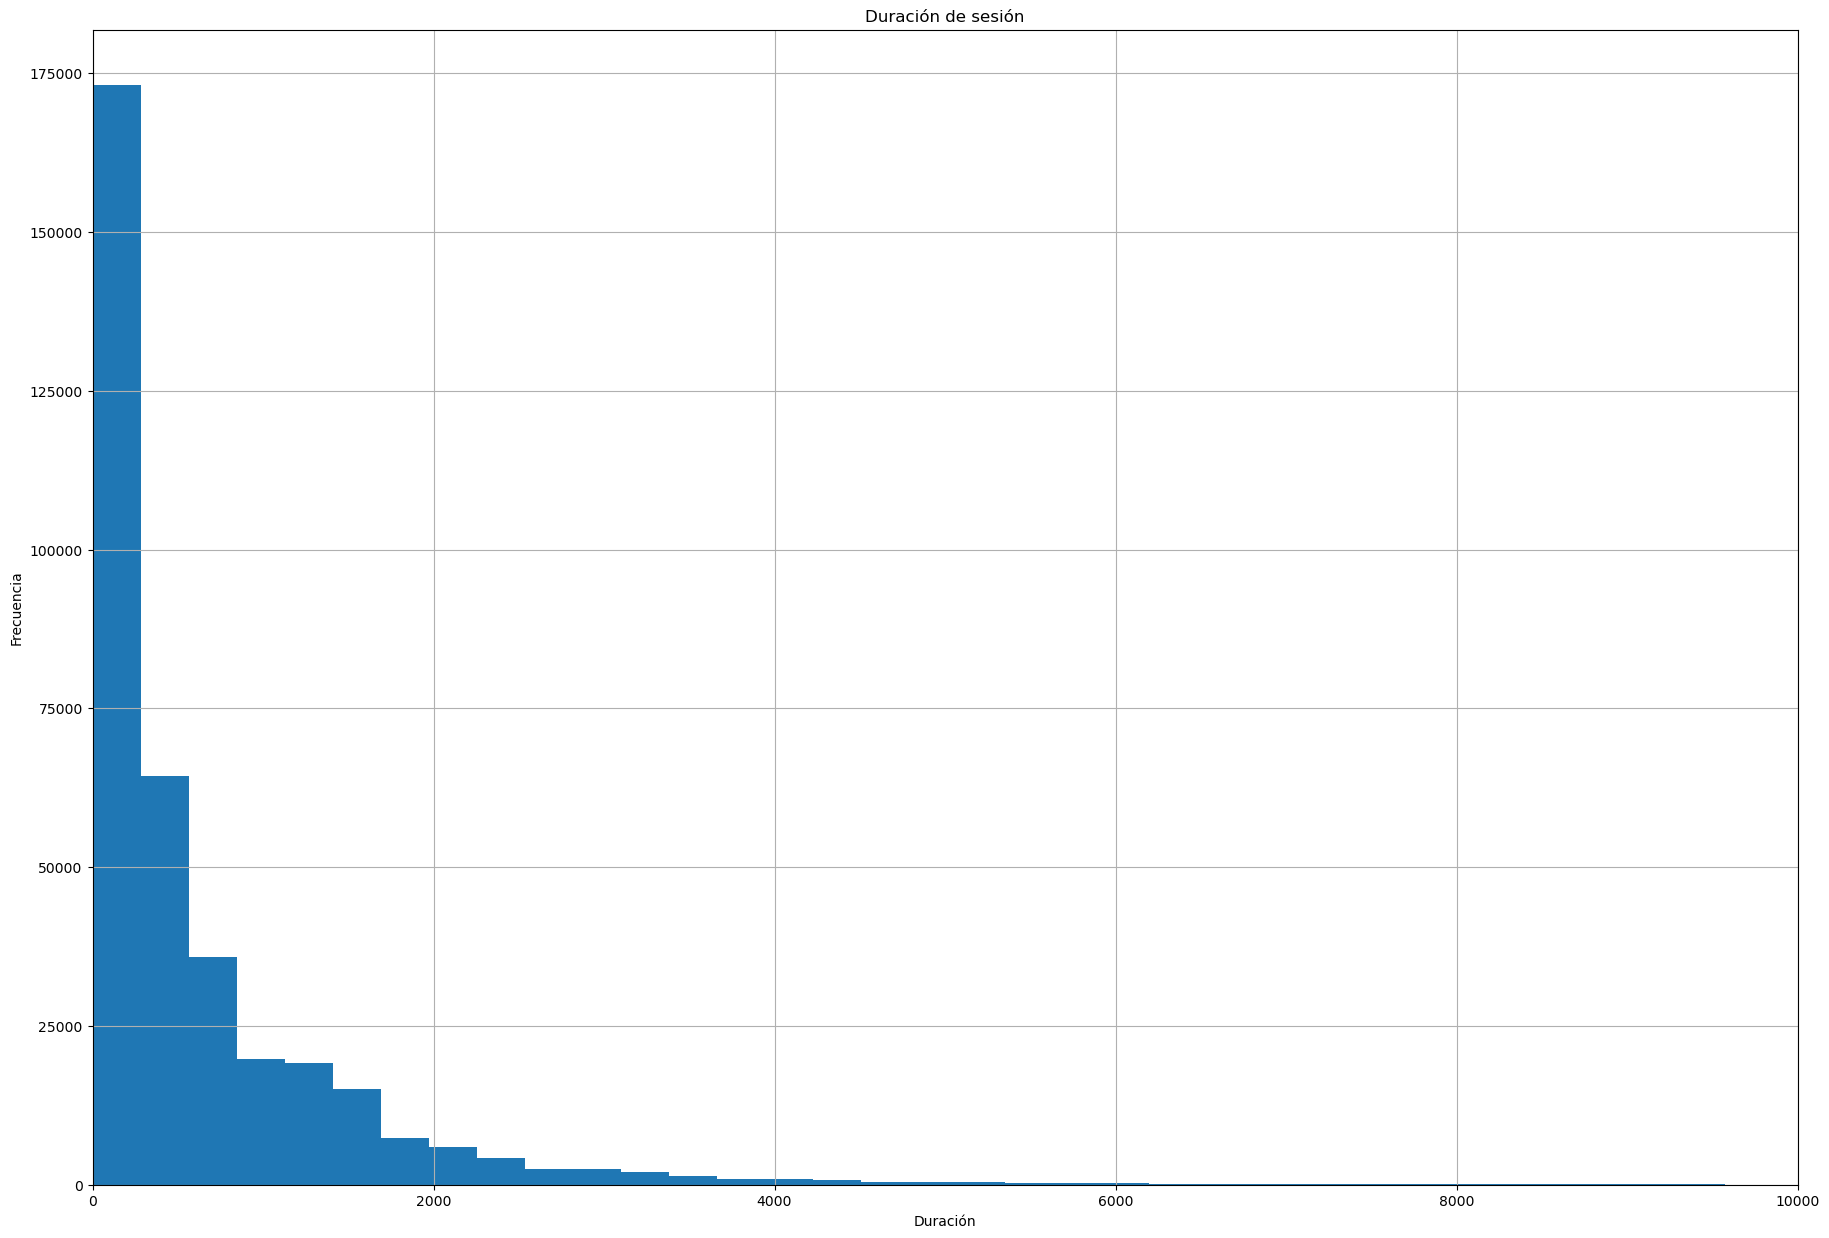

In [21]:
plt.figure(figsize= (22,15))
visits['session_duration_sec'].hist(bins=300).set(title = 'Duración de sesión', xlabel = 'Duración', ylabel = 'Frecuencia')
plt.xlim(0,10000)
plt.show()

In [22]:
print('La duración promedio de sesión es: {:.2f} segundos'.format(visits['session_duration_sec'].mean())) 
print('La duración mediana de sesión es: {:.2f} segundos'.format(visits['session_duration_sec'].median()))
print('La duración modal de sesión es: {} segundos'.format(visits['session_duration_sec'].mode()[0]))

La duración promedio de sesión es: 643.51 segundos
La duración mediana de sesión es: 300.00 segundos
La duración modal de sesión es: 60 segundos


### ¿Cuál es la tasa de retención de usuarios?

In [23]:
#encontrar tiempo de primera sesión
first_visits = visits.groupby('uid').agg({'session_start_ts': 'min'}).reset_index()
first_visits.columns = ['uid', 'first_session_start_ts']
first_visits.head()

,uid,first_session_start_ts
0,11863502262781,2018-03-01 17:27:00
1,49537067089222,2018-02-06 15:55:00
2,297729379853735,2017-06-07 18:47:00
3,313578113262317,2017-09-18 22:49:00
4,325320750514679,2017-09-30 14:29:00


In [24]:
#encontrar primera fecha y mes
first_visits['first_session_dt'] = first_visits['first_session_start_ts'].dt.date
first_visits['first_session_month'] = first_visits['first_session_start_ts'].dt.month

#combinar
visits_full = pd.merge(first_visits, visits, on = 'uid')

#calcular diferencia
visits_full['age_months'] = ((visits_full['session_month'] - visits_full['first_session_month']) / (np.timedelta64(1,'M').astype('int')))
visits_full.head()

,uid,first_session_start_ts,first_session_dt,first_session_month,device,session_end_ts,source_id,session_start_ts,session_month,session_week,session_date,session_duration_sec,age_months
0,11863502262781,2018-03-01 17:27:00,2018-03-01,3,touch,2018-03-01 17:33:00,3,2018-03-01 17:27:00,3,9,2018-03-01,360,0.0
1,49537067089222,2018-02-06 15:55:00,2018-02-06,2,touch,2018-02-06 15:57:00,2,2018-02-06 15:55:00,2,6,2018-02-06,120,0.0
2,297729379853735,2017-06-07 18:47:00,2017-06-07,6,desktop,2017-06-07 18:48:00,3,2017-06-07 18:47:00,6,23,2017-06-07,60,0.0
3,313578113262317,2017-09-18 22:49:00,2017-09-18,9,desktop,2018-03-11 17:29:00,2,2018-03-11 17:23:00,3,10,2018-03-11,360,-6.0
4,313578113262317,2017-09-18 22:49:00,2017-09-18,9,desktop,2017-09-18 23:07:00,2,2017-09-18 22:49:00,9,38,2017-09-18,1080,0.0


In [25]:
#análisis de cohortes
cohorts = visits_full.pivot_table(index='first_session_month',
                  columns='age_months',
                  values='uid',
                  aggfunc='nunique')
cohorts.fillna('')

age_months,-11.0,-10.0,-9.0,-8.0,-7.0,-6.0,-5.0,-4.0,-3.0,-2.0,-1.0,0.0,1.0,2.0,3.0,4.0,5.0,6.0
first_session_month,,,,,,,,,,,,,,,,,,
1,,,,,,,,,,,,22624.0,1351.0,890.0,565.0,458.0,,
2,,,,,,,,,,,,22197.0,1267.0,565.0,446.0,,,
3,,,,,,,,,,,,20589.0,861.0,557.0,,,,
4,,,,,,,,,,,,15709.0,760.0,,,,,
5,,,,,,,,,,,,15273.0,,,,,,
6,,,,,,,766.0,694.0,674.0,539.0,596.0,13259.0,1043.0,713.0,814.0,909.0,947.0,809.0
7,,,,,,596.0,601.0,510.0,376.0,361.0,,13140.0,737.0,674.0,738.0,765.0,633.0,
8,,,,,448.0,370.0,402.0,284.0,265.0,,,10181.0,783.0,640.0,639.0,510.0,,
9,,,,658.0,632.0,599.0,404.0,381.0,,,,16704.0,1428.0,1156.0,847.0,,,


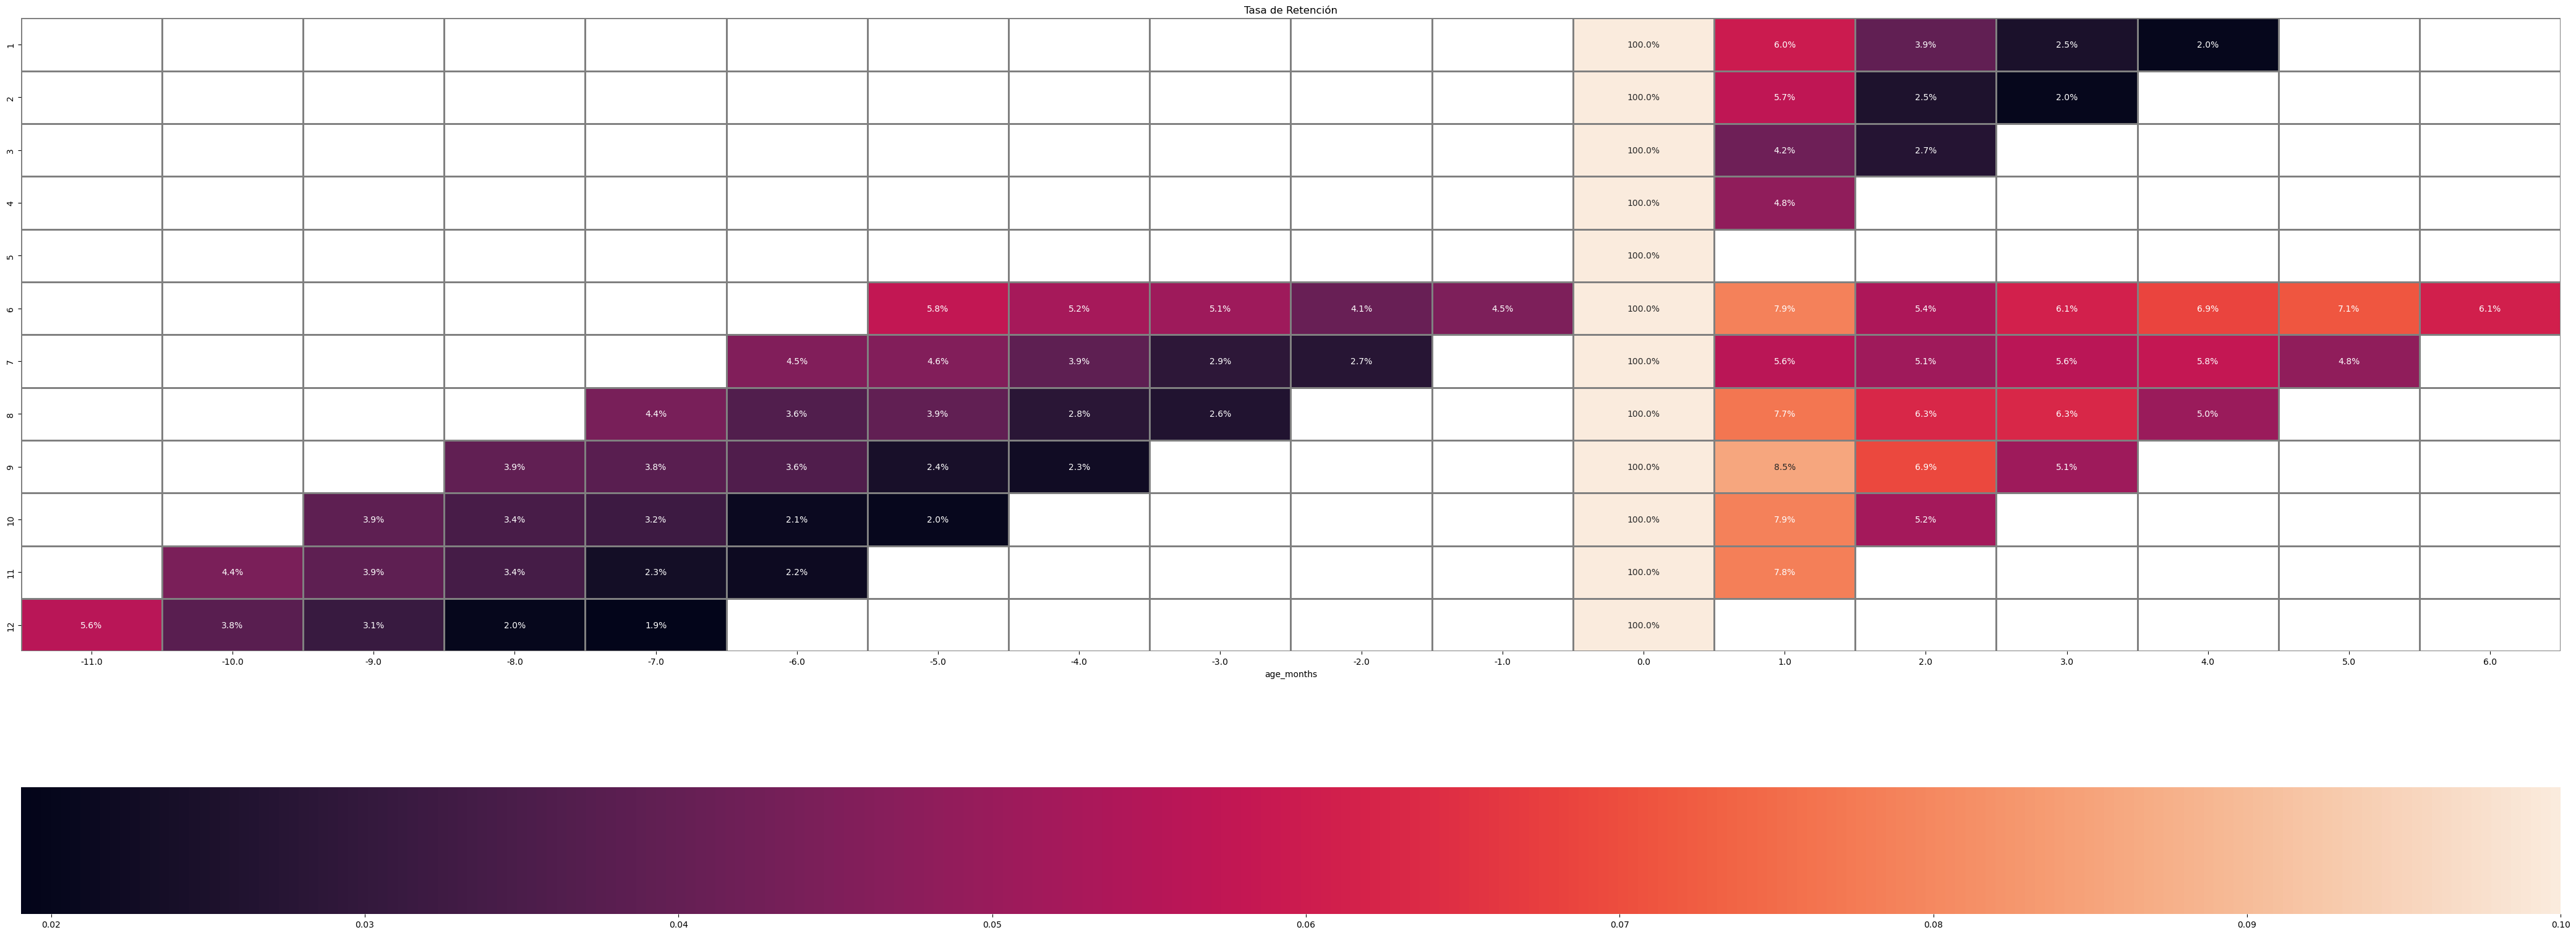

In [26]:
#Tasa de Retención
retention = pd.DataFrame()
for col in cohorts.columns:
    retention = pd.concat([retention, cohorts[col]/cohorts[0]], axis=1)
retention.columns = cohorts.columns
retention.index = [str(x)[0:10] for x in retention.index]
plt.figure(figsize=(53, 19))
sns.heatmap(retention, annot=True, fmt='.1%', linewidths=1, linecolor='grey',  vmax=0.1, cbar_kws= {'orientation': 'horizontal'} 
            ).set(title = 'Tasa de Retención')
plt.show()

In [27]:
print('{:.1%}'.format(retention[1].mean()))

6.6%


## Ventas

### ¿Cuándo empiezan a comprar las personas?

In [28]:
#agregar día y mes 
orders['buy_dt']  = orders['buy_ts'].dt.date
orders['order_month'] = orders['buy_ts'].dt.to_period('M')

# encontrar tiempo del primer pedido
first_orders = orders.groupby('uid').agg({'buy_ts': 'min'}).reset_index()
first_orders.columns = ['uid', 'first_order_ts']
first_orders['first_order_dt'] = first_orders['first_order_ts'].dt.date
first_orders['first_order_month'] = first_orders['first_order_ts'].dt.to_period('M')
first_orders.head()

#crear dataframe con primeros pedidos y primeras visitas
buyers = pd.merge(first_visits, first_orders, on='uid')
buyers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36523 entries, 0 to 36522
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   uid                     36523 non-null  uint64        
 1   first_session_start_ts  36523 non-null  datetime64[ns]
 2   first_session_dt        36523 non-null  object        
 3   first_session_month     36523 non-null  int32         
 4   first_order_ts          36523 non-null  datetime64[ns]
 5   first_order_dt          36523 non-null  object        
 6   first_order_month       36523 non-null  period[M]     
dtypes: datetime64[ns](2), int32(1), object(2), period[M](1), uint64(1)
memory usage: 1.8+ MB


In [29]:
buyers['first_order_dt'] = pd.to_datetime(buyers['first_order_dt'])
buyers['first_session_dt'] = pd.to_datetime(buyers['first_session_dt'])

buyers['days_to_first_purchase'] = ((buyers['first_order_ts'] - 
                                     buyers['first_session_start_ts']) / np.timedelta64(1,'D')).astype('int')                                     

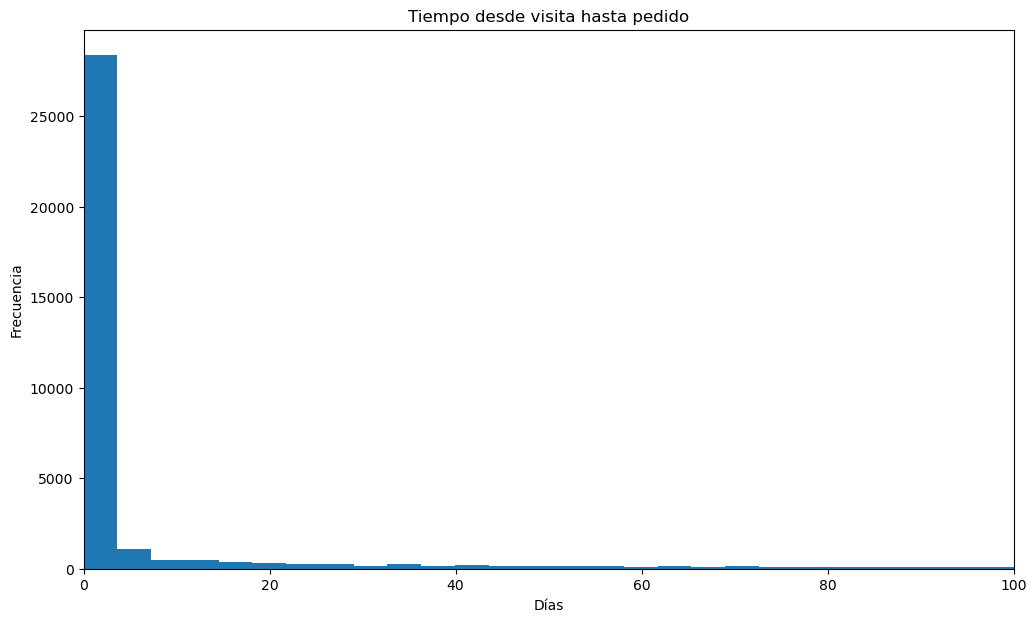

In [30]:
(buyers['days_to_first_purchase'].plot(kind='hist',bins=100, figsize=(12,7))
                                 .set(title = 'Tiempo desde visita hasta pedido', 
                                      xlabel = 'Días', 
                                      ylabel = 'Frecuencia'))
plt.xlim(0,100)
plt.show()

### ¿Cuántos pedidos hacen durante un período de tiempo determinado?

In [31]:
#encontrar número de clientes en cada cohorte
cohort_sizes = buyers.groupby('first_order_month').agg({'uid': 'nunique'}).reset_index()
cohort_sizes.rename(columns={'uid': 'n_buyers'}, inplace=True)

# agregar primer mes
cohorts = pd.merge(orders, buyers, how='inner', on='uid')\
.groupby(['first_order_month', 'order_month'])\
.agg({'revenue': 'count'}).reset_index()

print(cohorts.info())
print(cohorts.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype    
---  ------             --------------  -----    
 0   first_order_month  79 non-null     period[M]
 1   order_month        79 non-null     period[M]
 2   revenue            79 non-null     int64    
dtypes: int64(1), period[M](2)
memory usage: 2.0 KB
None
  first_order_month order_month  revenue
0           2017-06     2017-06     2354
1           2017-06     2017-07      177
2           2017-06     2017-08      174
3           2017-06     2017-09      226
4           2017-06     2017-10      292


In [32]:
# Calcular la edad en meses como la diferencia entre los períodos
cohorts['age_month'] = (cohorts['order_month'] - cohorts['first_order_month']).apply(lambda x: x.n)

# Renombrar las columnas según lo necesites
cohorts.columns = ['first_order_month', 'order_month', 'n_orders', 'age_month']

# Añadir clientes y contar órdenes
cohorts_report = pd.merge(cohort_sizes, cohorts, on='first_order_month')
cohorts_report['orders_per_buyer'] = cohorts_report['n_orders'] / cohorts_report['n_buyers']

cohorts.head()

,first_order_month,order_month,n_orders,age_month
0,2017-06,2017-06,2354,0
1,2017-06,2017-07,177,1
2,2017-06,2017-08,174,2
3,2017-06,2017-09,226,3
4,2017-06,2017-10,292,4


In [33]:
#reporte de cohorte
cohorts_ltv = cohorts_report.pivot_table(
    index='first_order_month', 
    columns='age_month', 
    values='orders_per_buyer', 
    aggfunc='sum'
).cumsum(axis=1)

cohorts_ltv.round(2).fillna('')

age_month,0,1,2,3,4,5,6,7,8,9,10,11
first_order_month,,,,,,,,,,,,
2017-06,1.16,1.25,1.34,1.45,1.59,1.7,1.84,1.92,2.03,2.1,2.15,2.19
2017-07,1.14,1.19,1.25,1.31,1.34,1.39,1.42,1.44,1.47,1.49,1.51,
2017-08,1.12,1.2,1.27,1.33,1.39,1.44,1.47,1.53,1.56,1.6,,
2017-09,1.14,1.22,1.28,1.35,1.37,1.42,1.46,1.48,1.5,,,
2017-10,1.14,1.22,1.25,1.28,1.31,1.34,1.35,1.38,,,,
2017-11,1.18,1.28,1.32,1.37,1.41,1.42,1.45,,,,,
2017-12,1.15,1.21,1.26,1.3,1.32,1.34,,,,,,
2018-01,1.12,1.19,1.24,1.25,1.28,,,,,,,
2018-02,1.12,1.18,1.21,1.22,,,,,,,,


In [34]:
print("Promedio de pedidos por comprador: ",round(cohorts_ltv[5].mean(), 2))

Promedio de pedidos por comprador:  1.43


### ¿Cuál es el tamaño promedio de compra?

In [35]:
print("La compra promedio es:", round(orders['revenue'].mean(),2))

La compra promedio es: 5.0


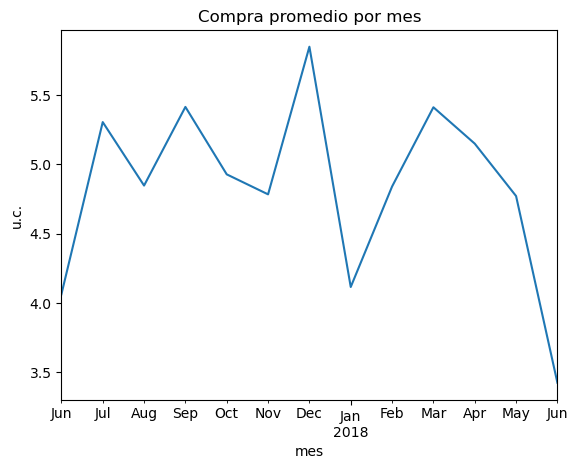

In [36]:
orders.pivot_table(index='order_month', values='revenue', aggfunc='mean').plot(legend=None).set(
    title = 'Compra promedio por mes', xlabel = 'mes', ylabel = 'u.c.')
plt.show()

### OPCIÓN

In [37]:
order_data = orders.merge(first_orders, how='left', on='uid') 

order_data.head()

,buy_ts,revenue,uid,buy_dt,order_month,first_order_ts,first_order_dt,first_order_month
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01,2017-06,2017-06-01 00:10:00,2017-06-01,2017-06
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01,2017-06,2017-06-01 00:25:00,2017-06-01,2017-06
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01,2017-06,2017-06-01 00:27:00,2017-06-01,2017-06
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01,2017-06,2017-06-01 00:29:00,2017-06-01,2017-06
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01,2017-06,2017-06-01 07:58:00,2017-06-01,2017-06


In [38]:
# Calcula los ingresos medianos por cohorte 
median_purchase=order_data.groupby(['first_order_month','order_month'])['revenue'].median().reset_index()

# Calcula el tiempo entre el pedido actual y el primer pedido 
median_purchase['age_month'] = ((median_purchase['order_month'] - median_purchase['first_order_month'])).apply(lambda x: x.n)

median_purchase_piv=median_purchase.pivot_table(
    index='first_order_month', 
    columns='age_month', 
    values='revenue', 
    aggfunc='mean'
)

median_purchase_piv.round(2).fillna('')

age_month,0,1,2,3,4,5,6,7,8,9,10,11
first_order_month,,,,,,,,,,,,
2017-06,2.44,3.6,3.05,4.28,3.3,2.44,3.05,3.05,3.39,3.67,4.28,1.83
2017-07,3.05,2.81,3.85,3.05,2.38,2.44,2.44,3.58,2.26,4.64,3.67,
2017-08,2.75,3.79,3.67,4.28,4.58,3.67,3.05,3.05,4.73,3.42,,
2017-09,2.44,4.89,2.93,5.53,2.93,4.89,3.4,3.48,3.91,,,
2017-10,2.44,2.75,2.69,2.72,3.3,2.62,2.38,2.57,,,,
2017-11,2.44,1.95,1.83,3.18,2.09,2.44,3.12,,,,,
2017-12,2.66,2.41,2.96,3.05,2.36,2.44,,,,,,
2018-01,2.44,2.44,2.44,3.05,2.08,,,,,,,
2018-02,2.44,2.44,2.33,2.26,,,,,,,,


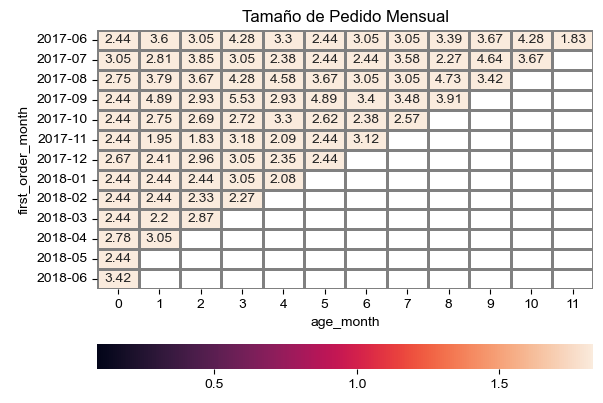

In [39]:
median_purchase_piv.index= median_purchase_piv.index.astype(str)
sns.heatmap(median_purchase_piv, annot=True, fmt='.3', linewidths=1, linecolor='grey', vmax=0.1, cbar_kws={'orientation':'horizontal'}).set(title = "Tamaño de Pedido Mensual")
sns.set(rc = {'figure.figsize':(50,30)})
sns.set(font_scale=4)

plt.show()

### FIN OPCIÓN

### ¿Cuánto dinero traen? (LTV)

In [40]:
buyers

,uid,first_session_start_ts,first_session_dt,first_session_month,first_order_ts,first_order_dt,first_order_month,days_to_first_purchase
0,313578113262317,2017-09-18 22:49:00,2017-09-18,9,2018-01-03 21:51:00,2018-01-03,2018-01,106
1,1575281904278712,2017-06-03 10:13:00,2017-06-03,6,2017-06-03 10:13:00,2017-06-03,2017-06,0
2,2429014661409475,2017-10-11 17:14:00,2017-10-11,10,2017-10-11 18:33:00,2017-10-11,2017-10,0
3,2464366381792757,2018-01-27 20:10:00,2018-01-27,1,2018-01-28 15:54:00,2018-01-28,2018-01,0
4,2551852515556206,2017-11-24 10:14:00,2017-11-24,11,2017-11-24 10:14:00,2017-11-24,2017-11,0
...,...,...,...,...,...,...,...,...
36518,18445147675727495770,2017-08-20 13:30:00,2017-08-20,8,2017-11-24 09:03:00,2017-11-24,2017-11,95
36519,18445407535914413204,2017-09-22 23:48:00,2017-09-22,9,2017-09-22 23:55:00,2017-09-22,2017-09,0
36520,18445601152732270159,2017-08-07 11:51:00,2017-08-07,8,2018-03-26 22:54:00,2018-03-26,2018-03,231
36521,18446156210226471712,2017-11-07 10:01:00,2017-11-07,11,2018-02-18 19:34:00,2018-02-18,2018-02,103


In [41]:
# recordar sobre compradores
cohort_sizes = buyers.groupby('first_order_month').agg({'uid': 'nunique'}).reset_index()
cohort_sizes.rename(columns={'uid': 'n_buyers'}, inplace=True)

#agregar primer mes
cohorts = pd.merge(orders, buyers, how='inner', on='uid')\
            .groupby(['first_order_month', 'order_month'])\
            .agg({'revenue': 'sum'}).reset_index()

cohorts.head()

,first_order_month,order_month,revenue
0,2017-06,2017-06,9557.49
1,2017-06,2017-07,981.82
2,2017-06,2017-08,885.34
3,2017-06,2017-09,1931.30
4,2017-06,2017-10,2068.58


In [42]:
#calcular edad
cohorts['age_month'] = (cohorts['order_month'] - cohorts['first_order_month']).apply(lambda x: x.n)
cohorts.columns = ['first_order_month', 'order_month', 'revenue', 'age_month']

#  agregar clientes y calcular ltv
cohorts_report = pd.merge(cohort_sizes, cohorts, on = 'first_order_month')
cohorts_report['ltv'] = cohorts_report['revenue'] / cohorts_report['n_buyers']

In [43]:
cohorts_ltv = cohorts_report.pivot_table(
    index='first_order_month', 
    columns='age_month', 
    values='ltv', 
    aggfunc='sum'
).cumsum(axis=1)

cohorts_ltv.round(2).fillna('')

age_month,0,1,2,3,4,5,6,7,8,9,10,11
first_order_month,,,,,,,,,,,,
2017-06,4.72,5.21,5.65,6.6,7.62,8.36,9.31,9.89,10.45,11.05,11.62,11.88
2017-07,6.01,6.35,6.97,7.33,7.5,7.66,7.78,7.92,8.08,8.23,8.39,
2017-08,5.28,5.75,6.21,6.6,7.09,7.38,7.59,7.99,8.28,8.47,,
2017-09,5.64,6.76,7.28,11.26,11.66,12.31,13.01,13.25,13.44,,,
2017-10,5.00,5.54,5.73,5.89,6.04,6.16,6.24,6.36,,,,
2017-11,5.15,5.55,5.75,6.08,6.23,6.28,6.4,,,,,
2017-12,4.74,5.0,5.92,6.99,7.3,7.64,,,,,,
2018-01,4.14,4.43,4.73,4.88,4.94,,,,,,,
2018-02,4.16,4.44,4.51,4.59,,,,,,,,


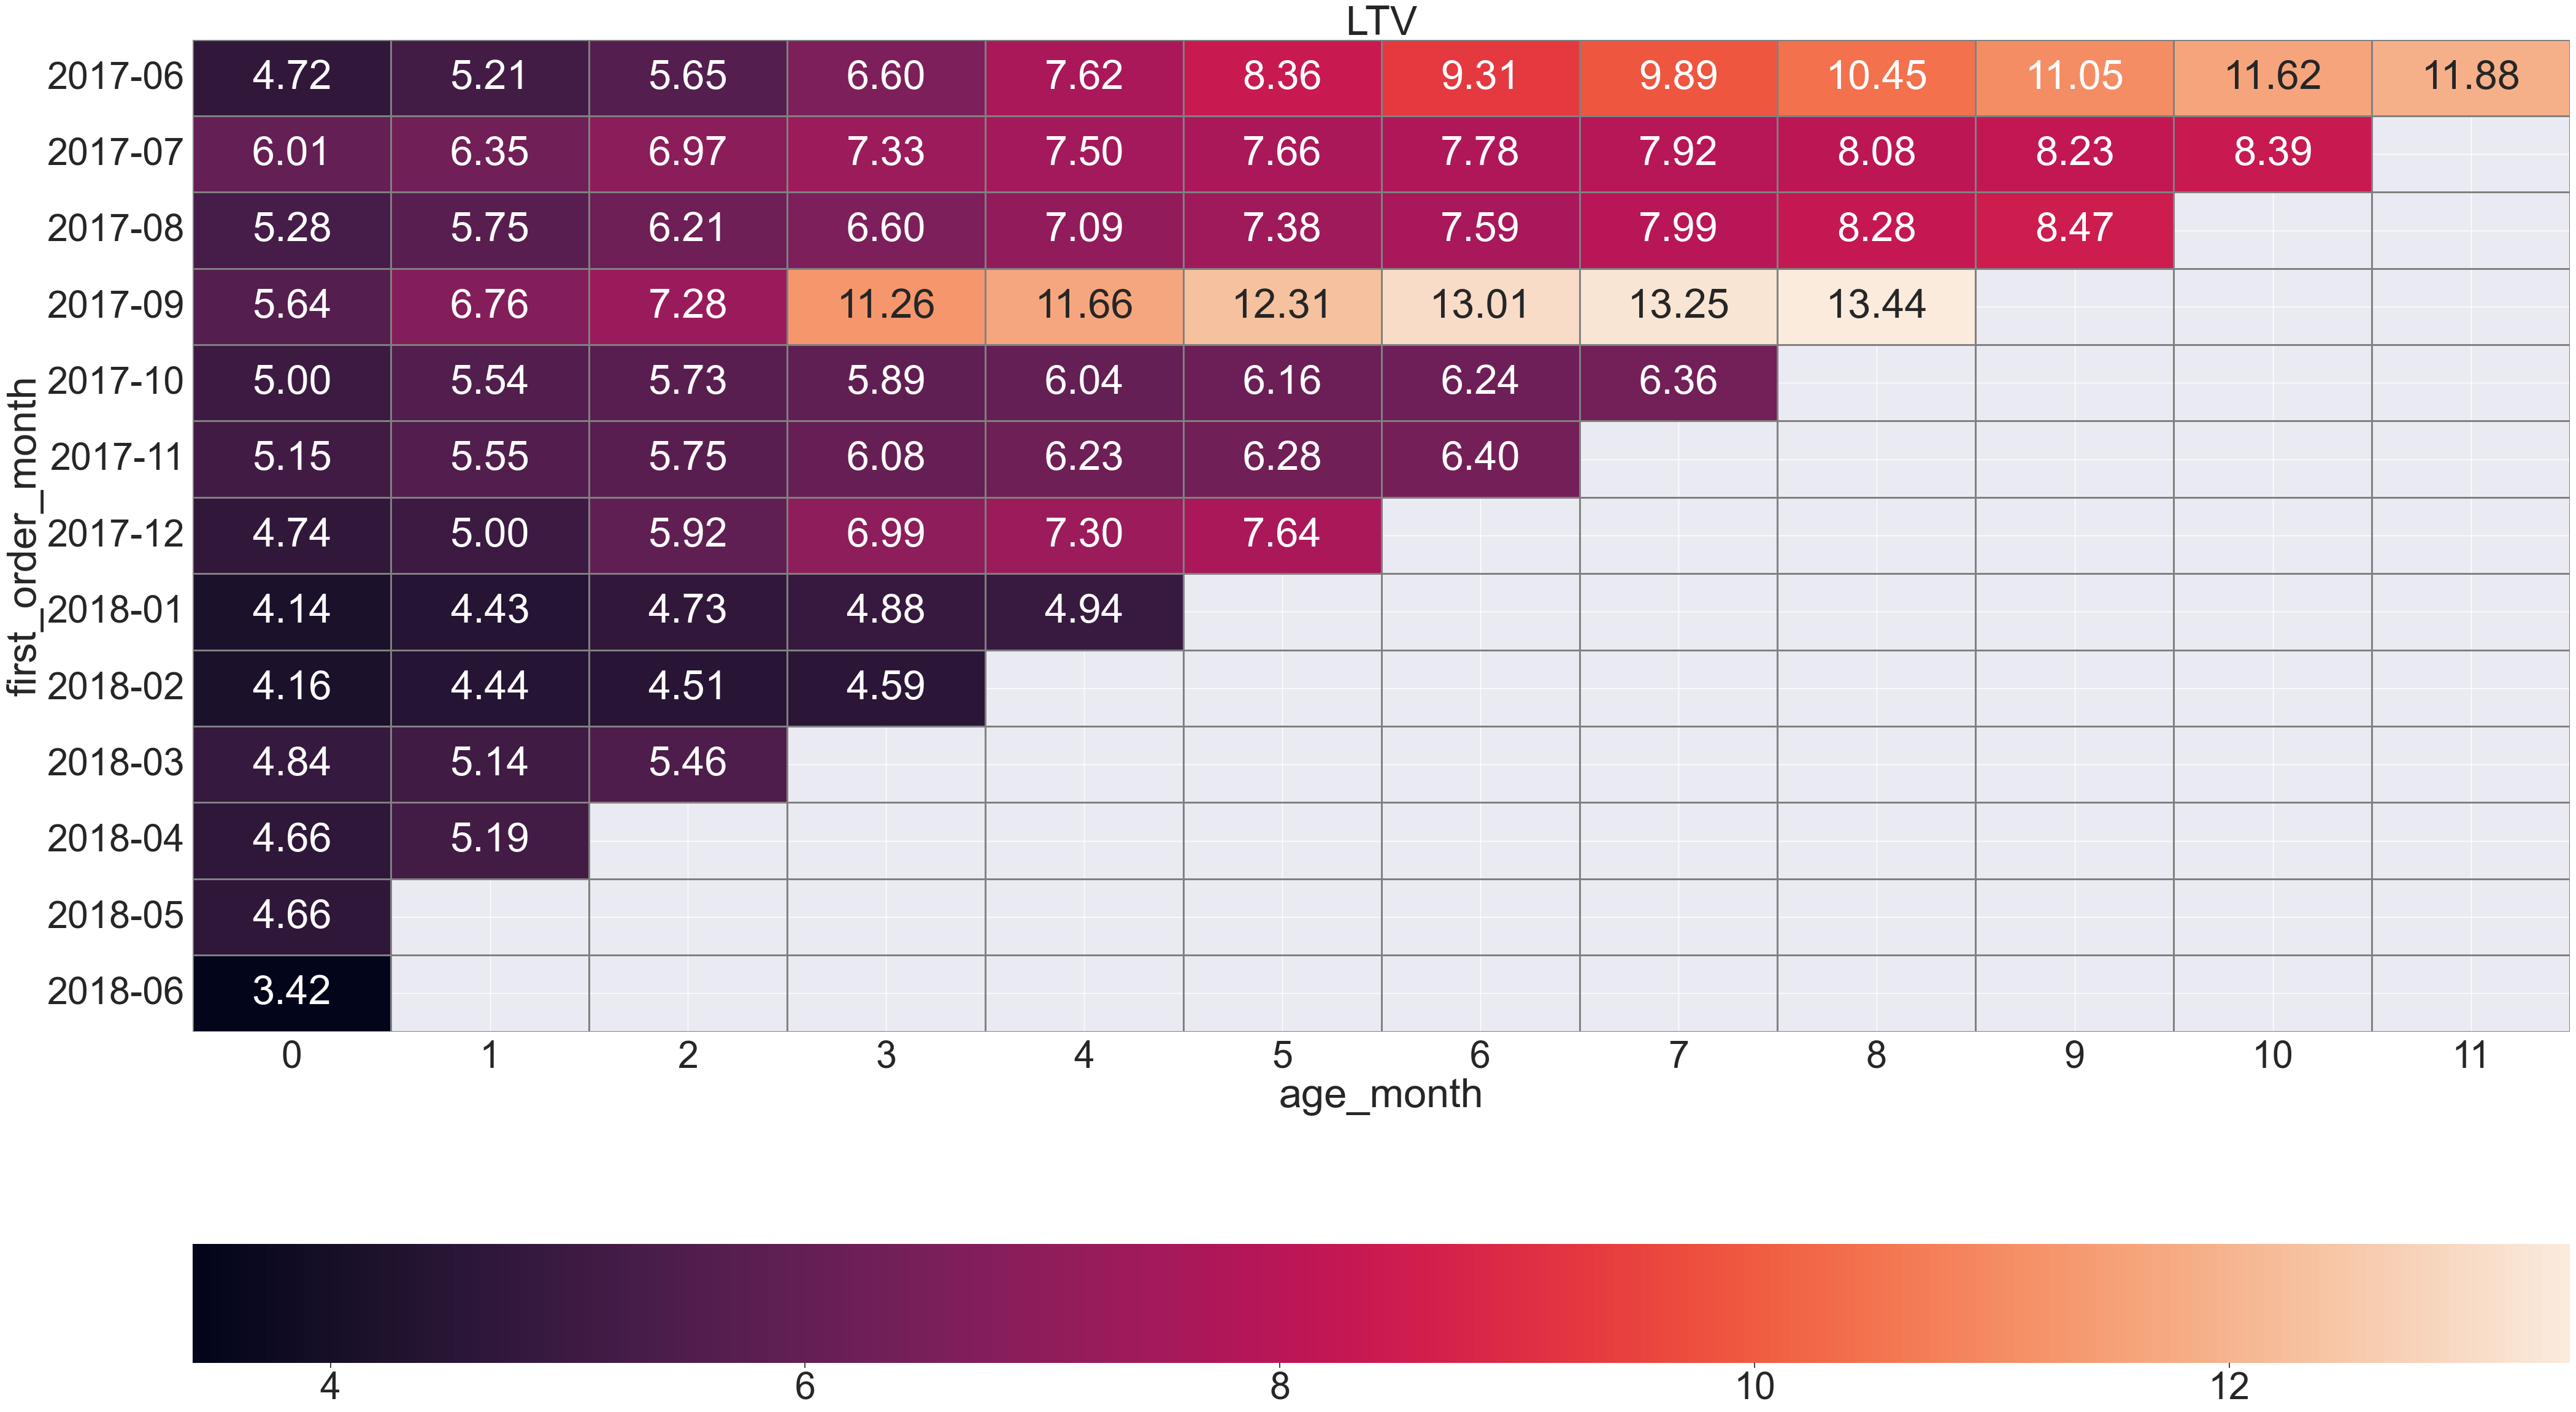

In [44]:
cohorts_ltv.index=cohorts_ltv.index.astype(str)
sns.heatmap(cohorts_ltv, annot=True, fmt='.2f', linewidths=1, linecolor='grey', cbar_kws= {'orientation': 'horizontal'} 
            ).set(title ='LTV')
plt.show()

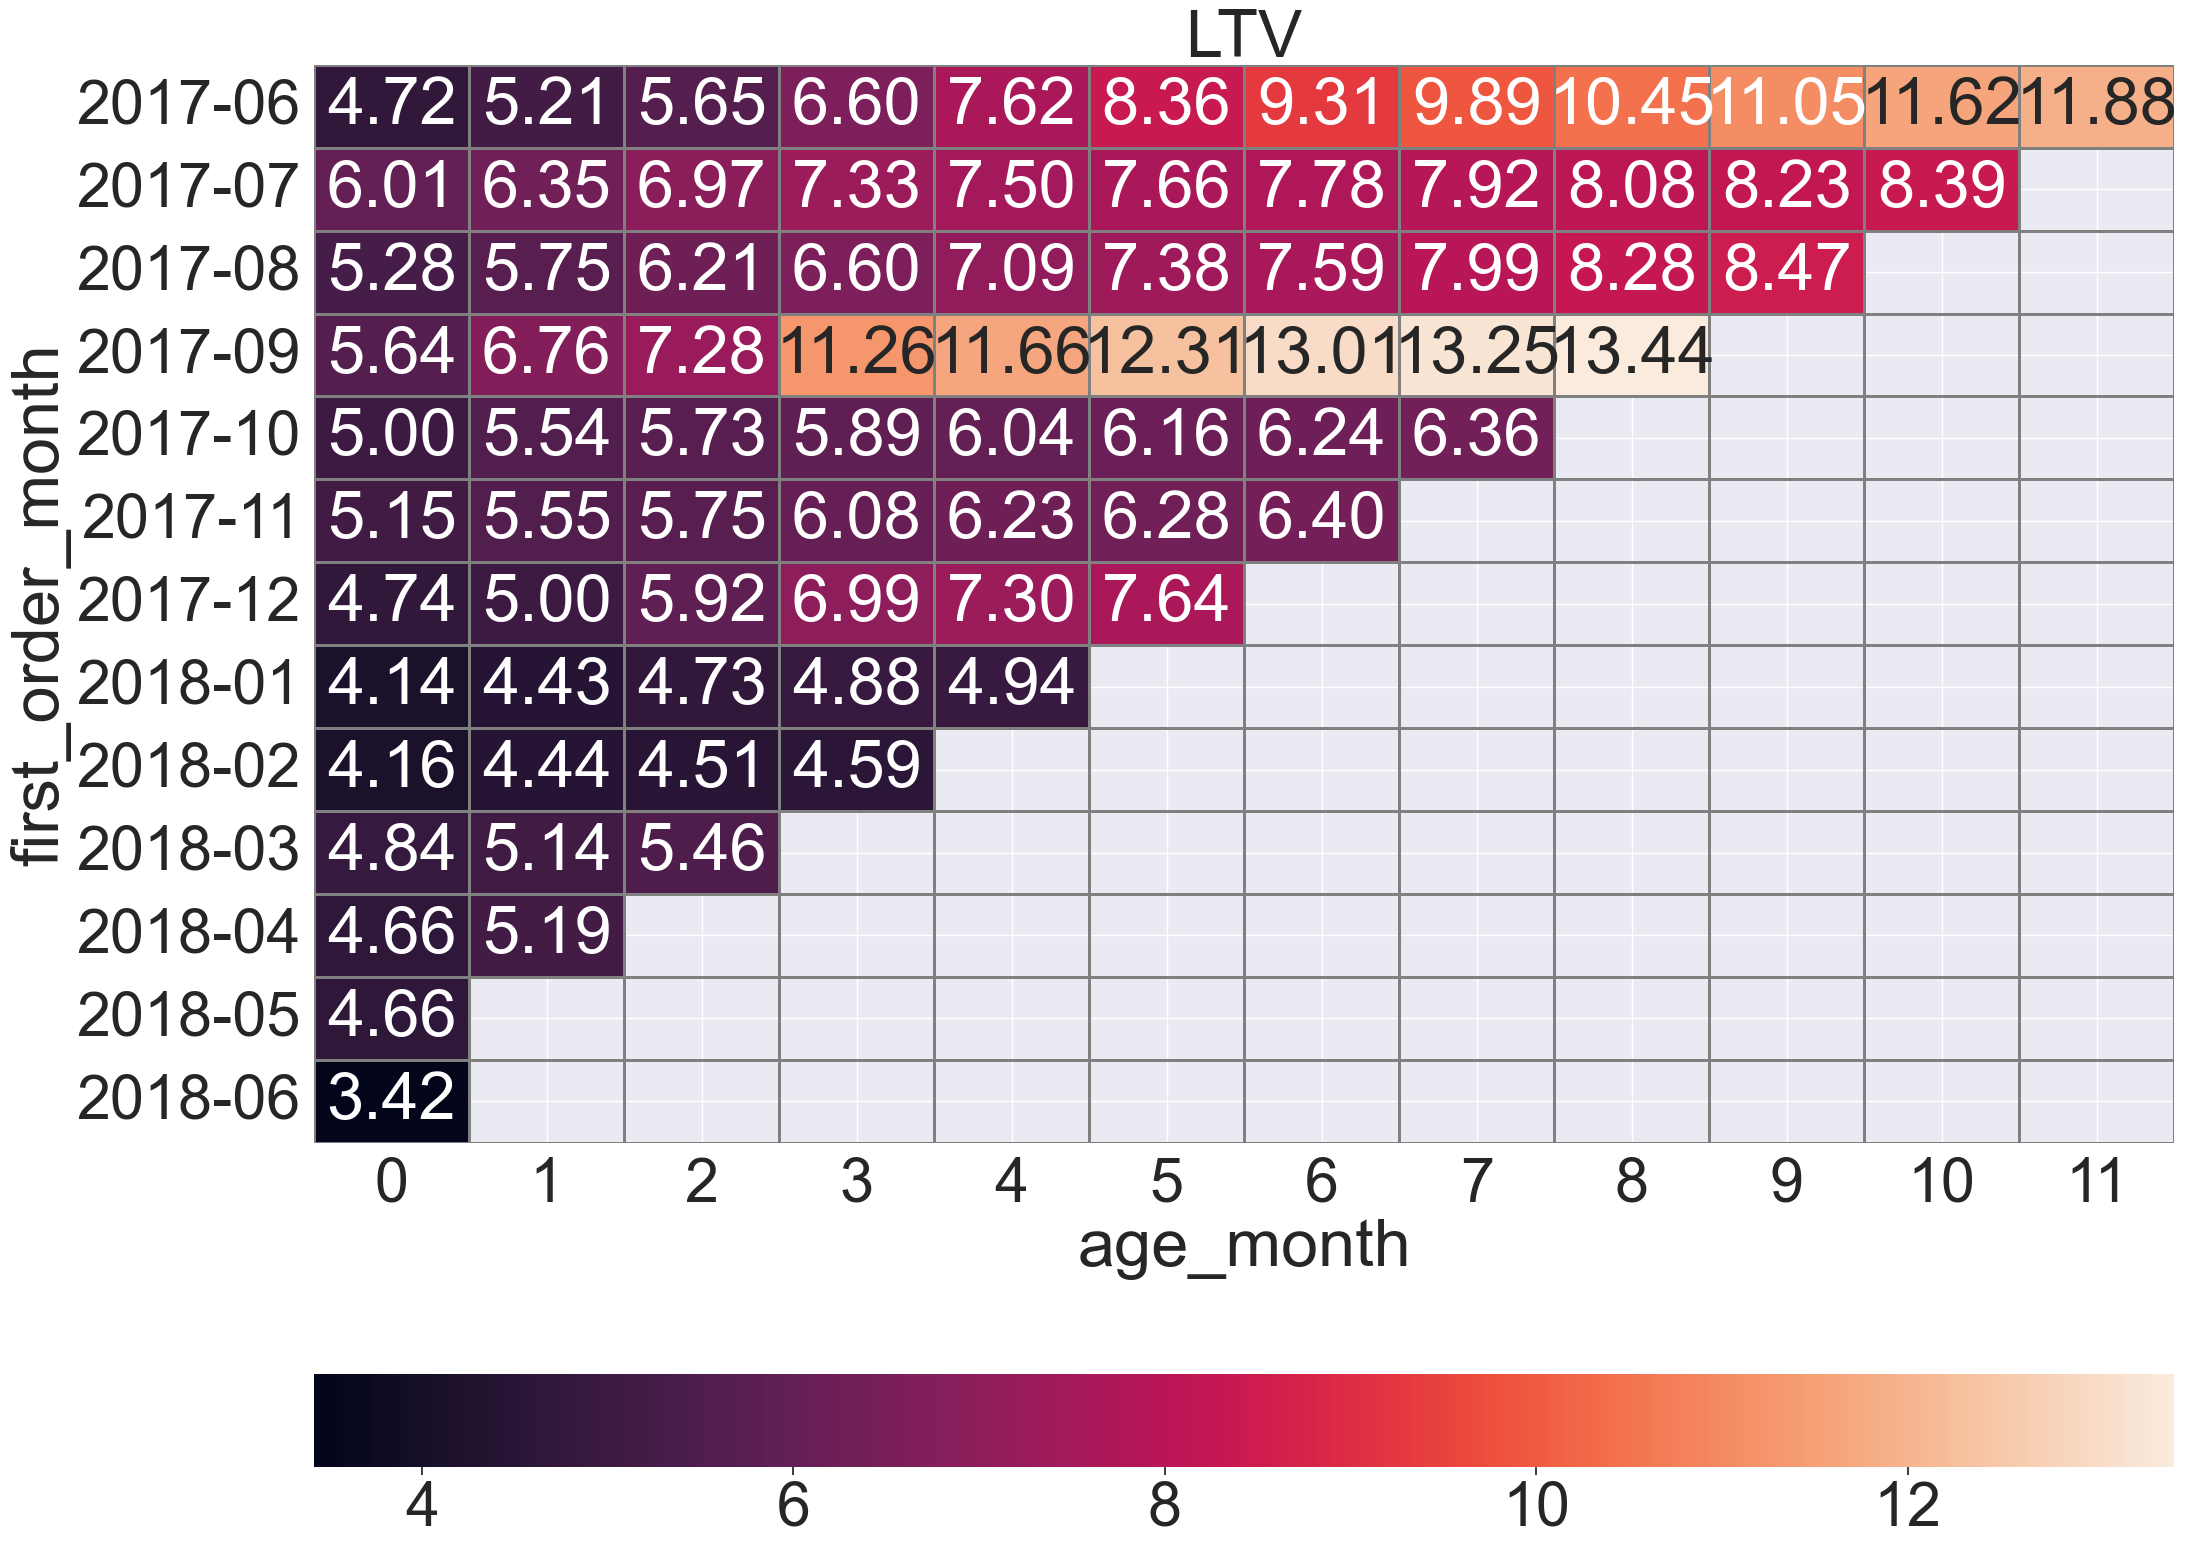

In [45]:
plt.figure(figsize=(24, 20))
sns.heatmap(cohorts_ltv, annot=True, fmt='.2f', linewidths=1, linecolor='grey', cbar_kws= {'orientation': 'horizontal'} 
            ).set(title ='LTV') 
plt.show()

In [46]:
print("LTV promedio en 6 meses es:", round(cohorts_ltv[5].mean(),2))

LTV promedio en 6 meses es: 7.97


## Marketing

### ¿Cuánto dinero se gastó? En general/por fuente/a lo largo del tiempo

In [47]:
print('Costos totales {}'.format(costs['costs'].sum()))

Costos totales 329131.62


In [48]:
#agregar mes
costs['costs_month'] = costs['dt'].dt.to_period('M')

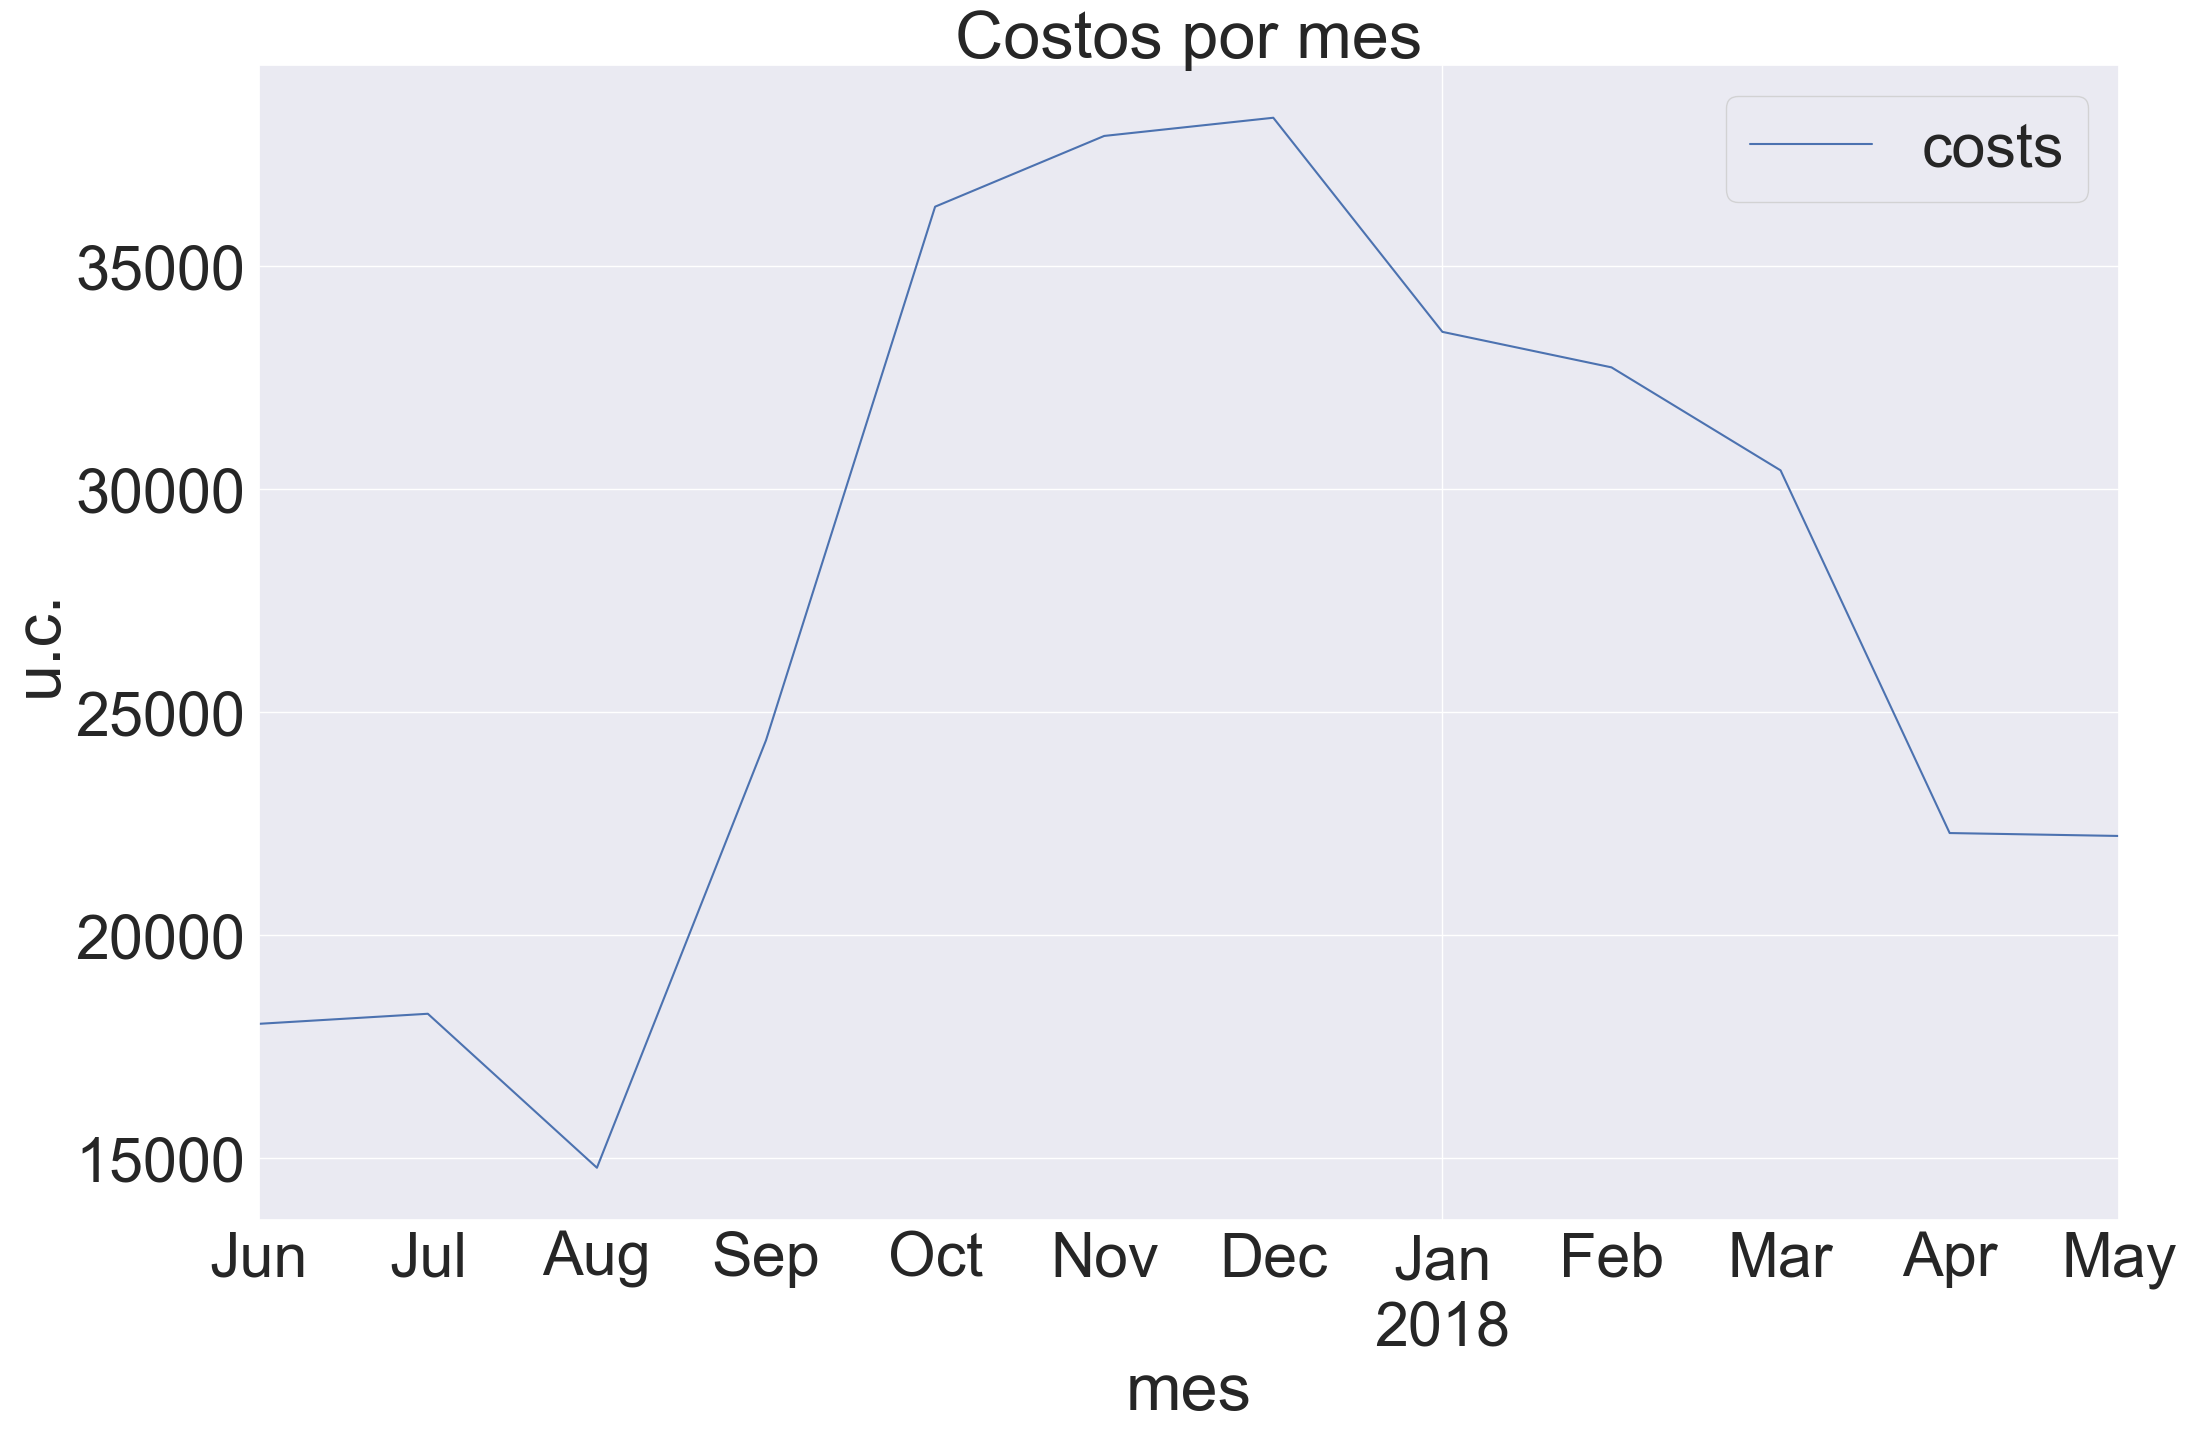

In [49]:
(costs.pivot_table(index='costs_month', values='costs', aggfunc='sum')
      .plot(figsize=(24,15), title='Costos por mes', xlabel = 'mes', ylabel = 'u.c.'))
plt.show()

In [50]:
print('Costos por fuente:')    
print(costs.groupby('source_id').agg({'costs': 'sum'}))

Costos por fuente:
               costs
source_id           
1           20833.27
2           42806.04
3          141321.63
4           61073.60
5           51757.10
9            5517.49
10           5822.49


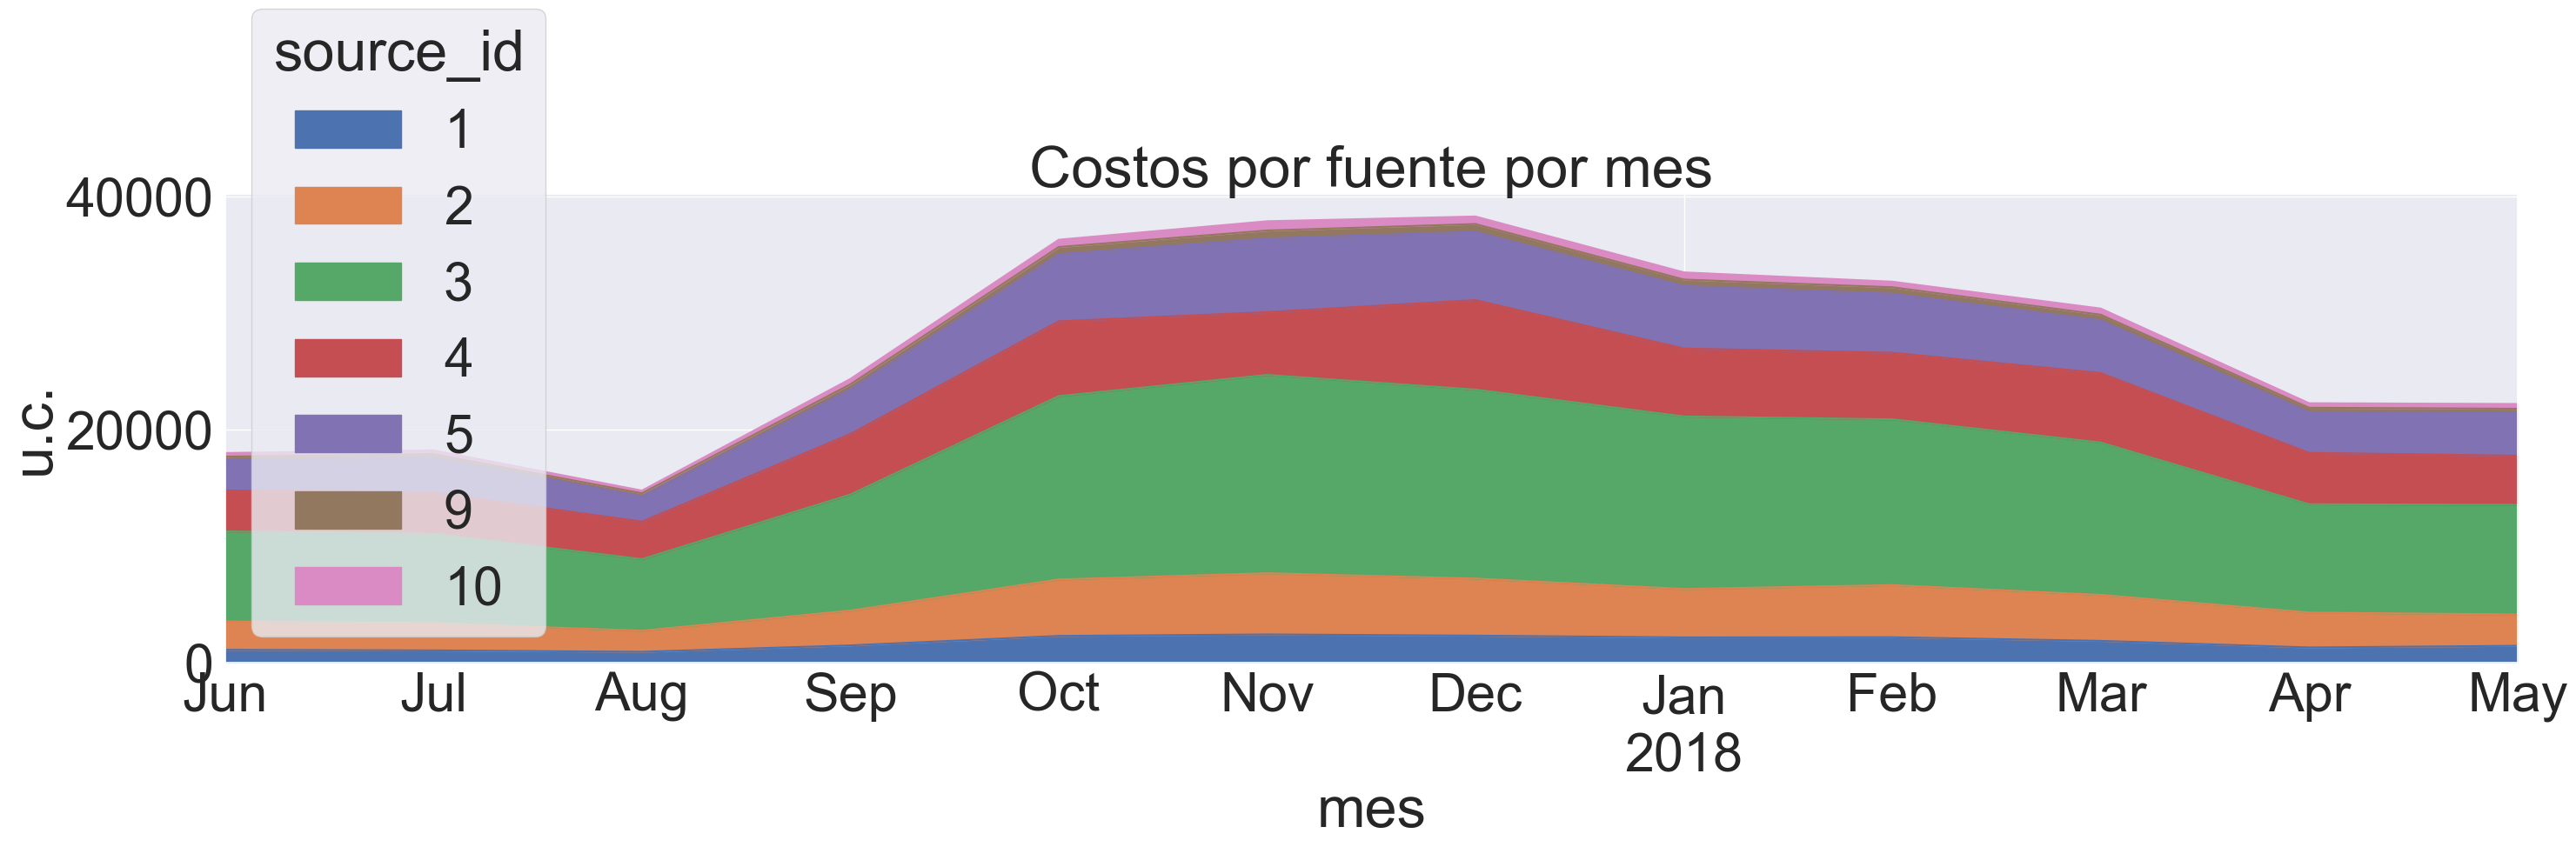

In [51]:
(costs.pivot_table(index='costs_month', columns='source_id', values='costs', aggfunc='sum')
      .plot
      .area(figsize=(34,7), title='Costos por fuente por mes', xlabel = 'mes', ylabel = 'u.c.'))
plt.show()

### ¿Cuánto costó la adquisición de clientes de cada una de las fuentes?

In [52]:
print("CAC promedio es:", round(costs['costs'].sum() / orders['uid'].nunique(), 2))

CAC promedio es: 9.01


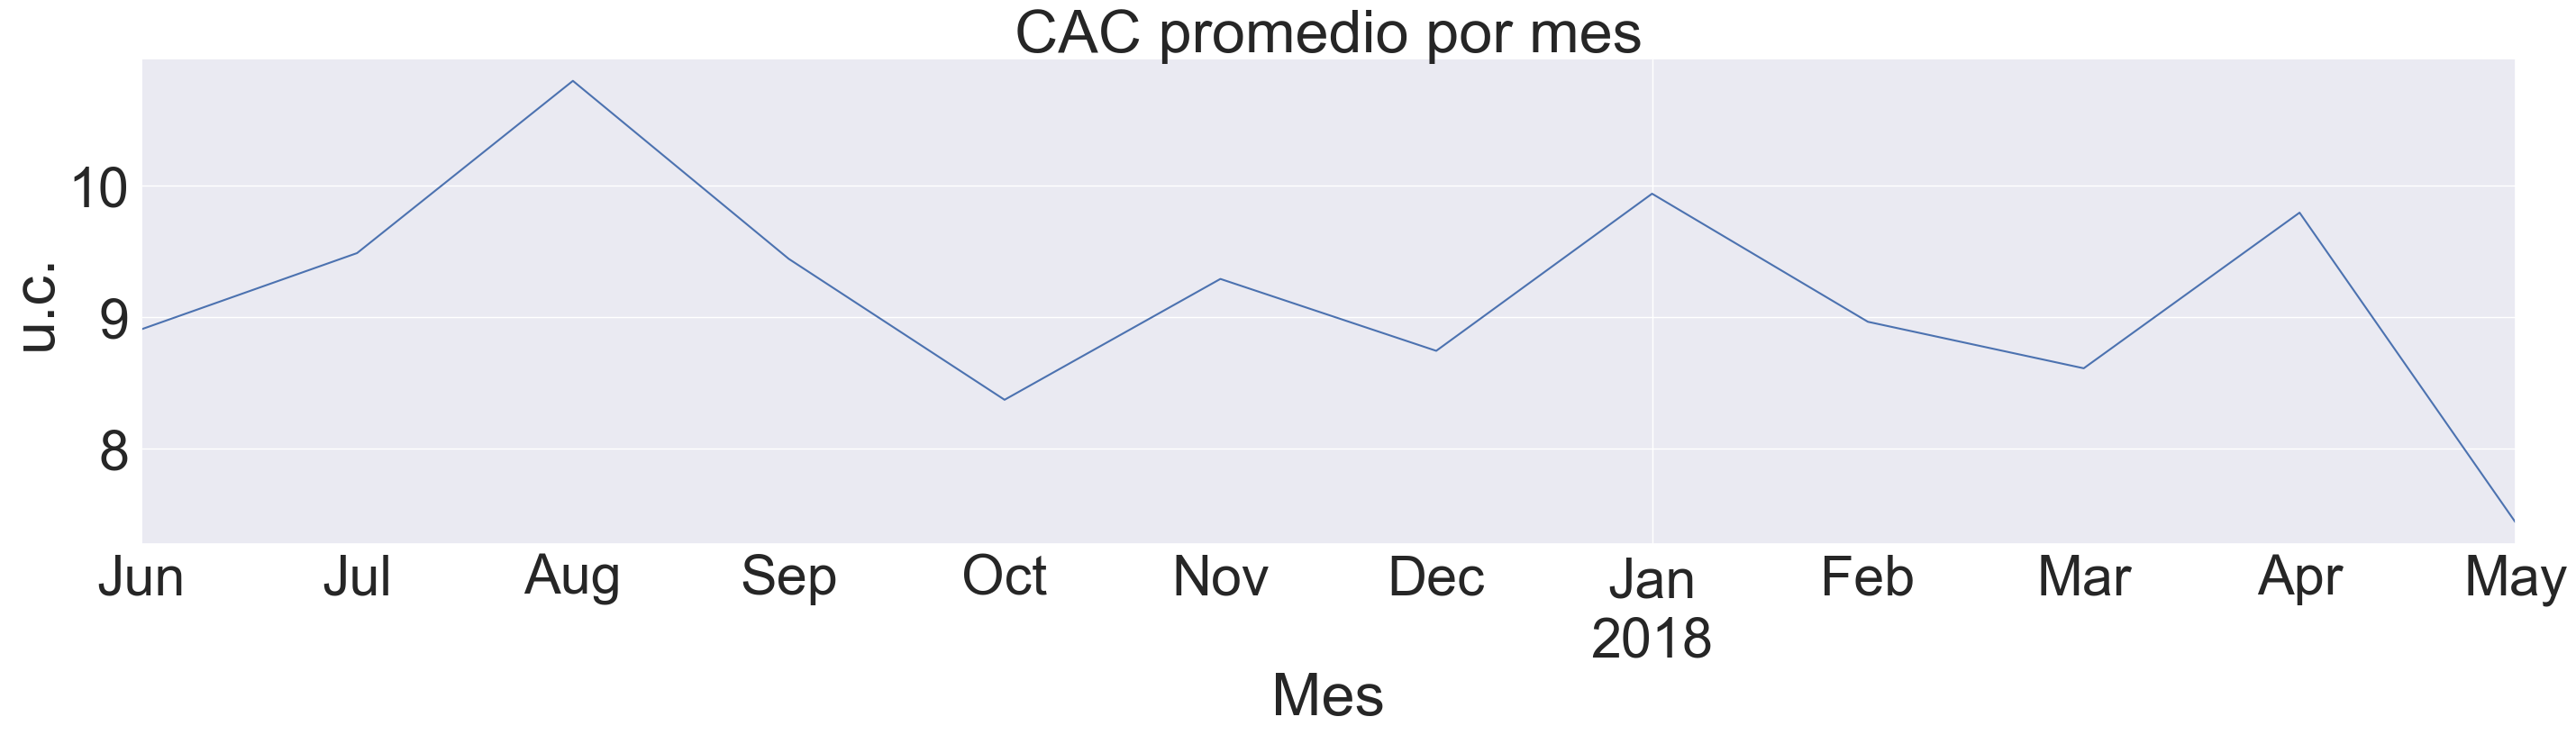

In [53]:
#CAC por mes
CAC_by_month = pd.merge(costs.groupby('costs_month').agg({'costs': 'sum'}), 
                        buyers.groupby('first_order_month').agg({'uid': 'nunique'}), 
                        left_index=True, 
                        right_index=True)
CAC_by_month['cac'] = CAC_by_month['costs']  / CAC_by_month['uid'] 

CAC_by_month['cac'].plot(figsize=(34,7), title='CAC promedio por mes', xlabel = 'Mes', ylabel = 'u.c.');

In [54]:
#encontrar primera fuente por visitante
users = visits_full.sort_values('session_start_ts').groupby('uid').first()
users = users[['source_id']]
buyers = pd.merge(buyers, users, left_on='uid', right_index=True)

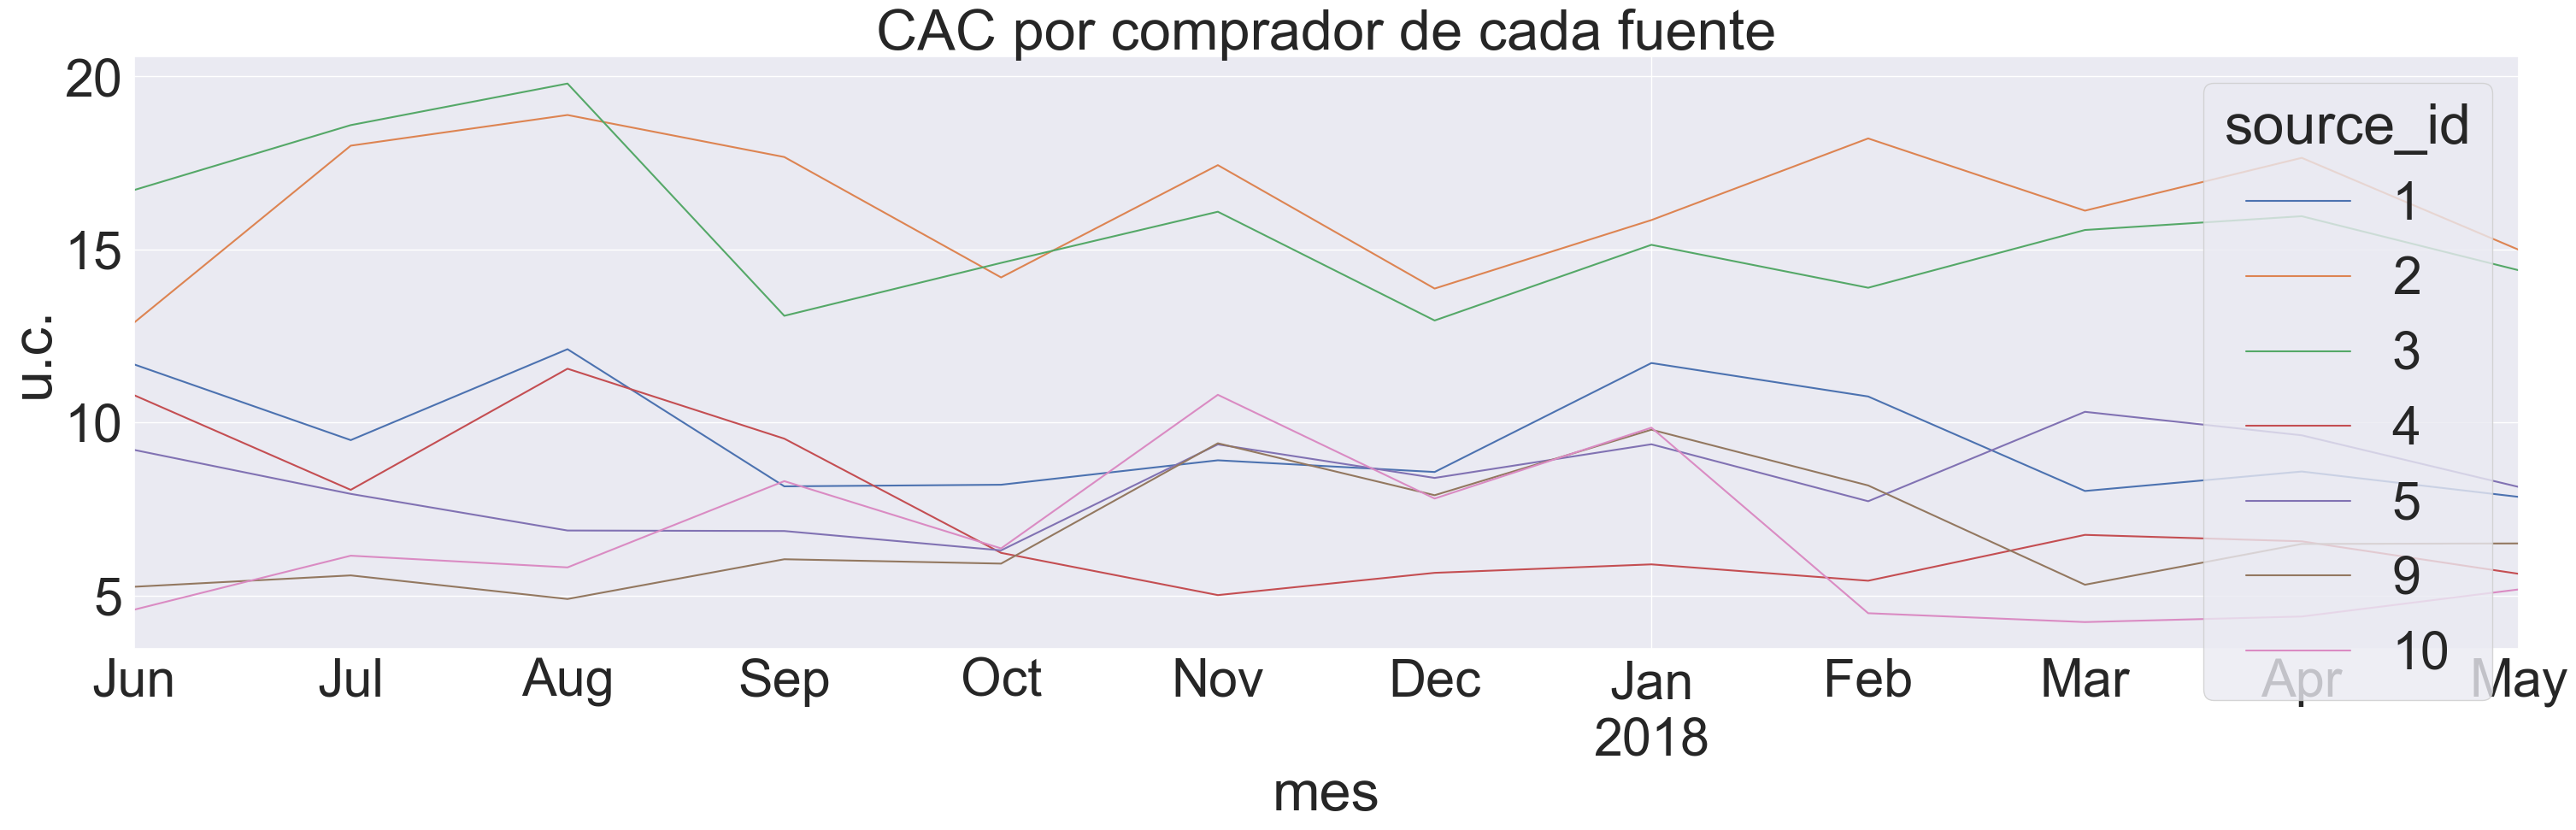

In [55]:
buyers_daily = buyers.groupby(['source_id', 'first_order_dt']).agg({'uid': 'count'}).reset_index()
buyers_daily.rename(columns={'uid': 'n_buyers'}, inplace=True)
buyers_daily['first_order_dt'] = pd.to_datetime(buyers_daily['first_order_dt'])

costs_ = pd.merge(buyers_daily, costs, left_on=['source_id', 'first_order_dt'], right_on=['source_id', 'dt'])
costs_['cac'] = costs_['costs']/costs_['n_buyers']

costs_.pivot_table(index=['costs_month'], columns='source_id', values='cac', aggfunc='mean').plot(
    figsize=(36,9), title='CAC por comprador de cada fuente', xlabel = 'mes', ylabel = 'u.c.')
plt.show()

In [56]:
#CAC promedio por fuente
costs_.groupby('source_id').agg({'cac': 'mean'}).round(2)

,cac
source_id,
1,9.49
2,16.29
3,15.58
4,7.27
5,8.34
9,6.84
10,6.56


### ¿Qué tan rentables fueron las inversiones? (ROI)

Traza gráficos para mostrar cómo difieren estas métricas para varios dispositivos y fuentes de anuncios y cómo cambian con el tiempo.

In [57]:
orders

,buy_ts,revenue,uid,buy_dt,order_month
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01,2017-06
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01,2017-06
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01,2017-06
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01,2017-06
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01,2017-06
...,...,...,...,...,...
50410,2018-05-31 23:50:00,4.64,12296626599487328624,2018-05-31,2018-05
50411,2018-05-31 23:50:00,5.80,11369640365507475976,2018-05-31,2018-05
50412,2018-05-31 23:54:00,0.30,1786462140797698849,2018-05-31,2018-05
50413,2018-05-31 23:56:00,3.67,3993697860786194247,2018-05-31,2018-05


In [58]:
#crear mapa de calor de pedidos por mes y combinar con compradores
month_revenue = orders.groupby(['uid', 'order_month']).agg({'revenue': 'sum'}).reset_index()
buyers = buyers.merge(month_revenue,on = 'uid')

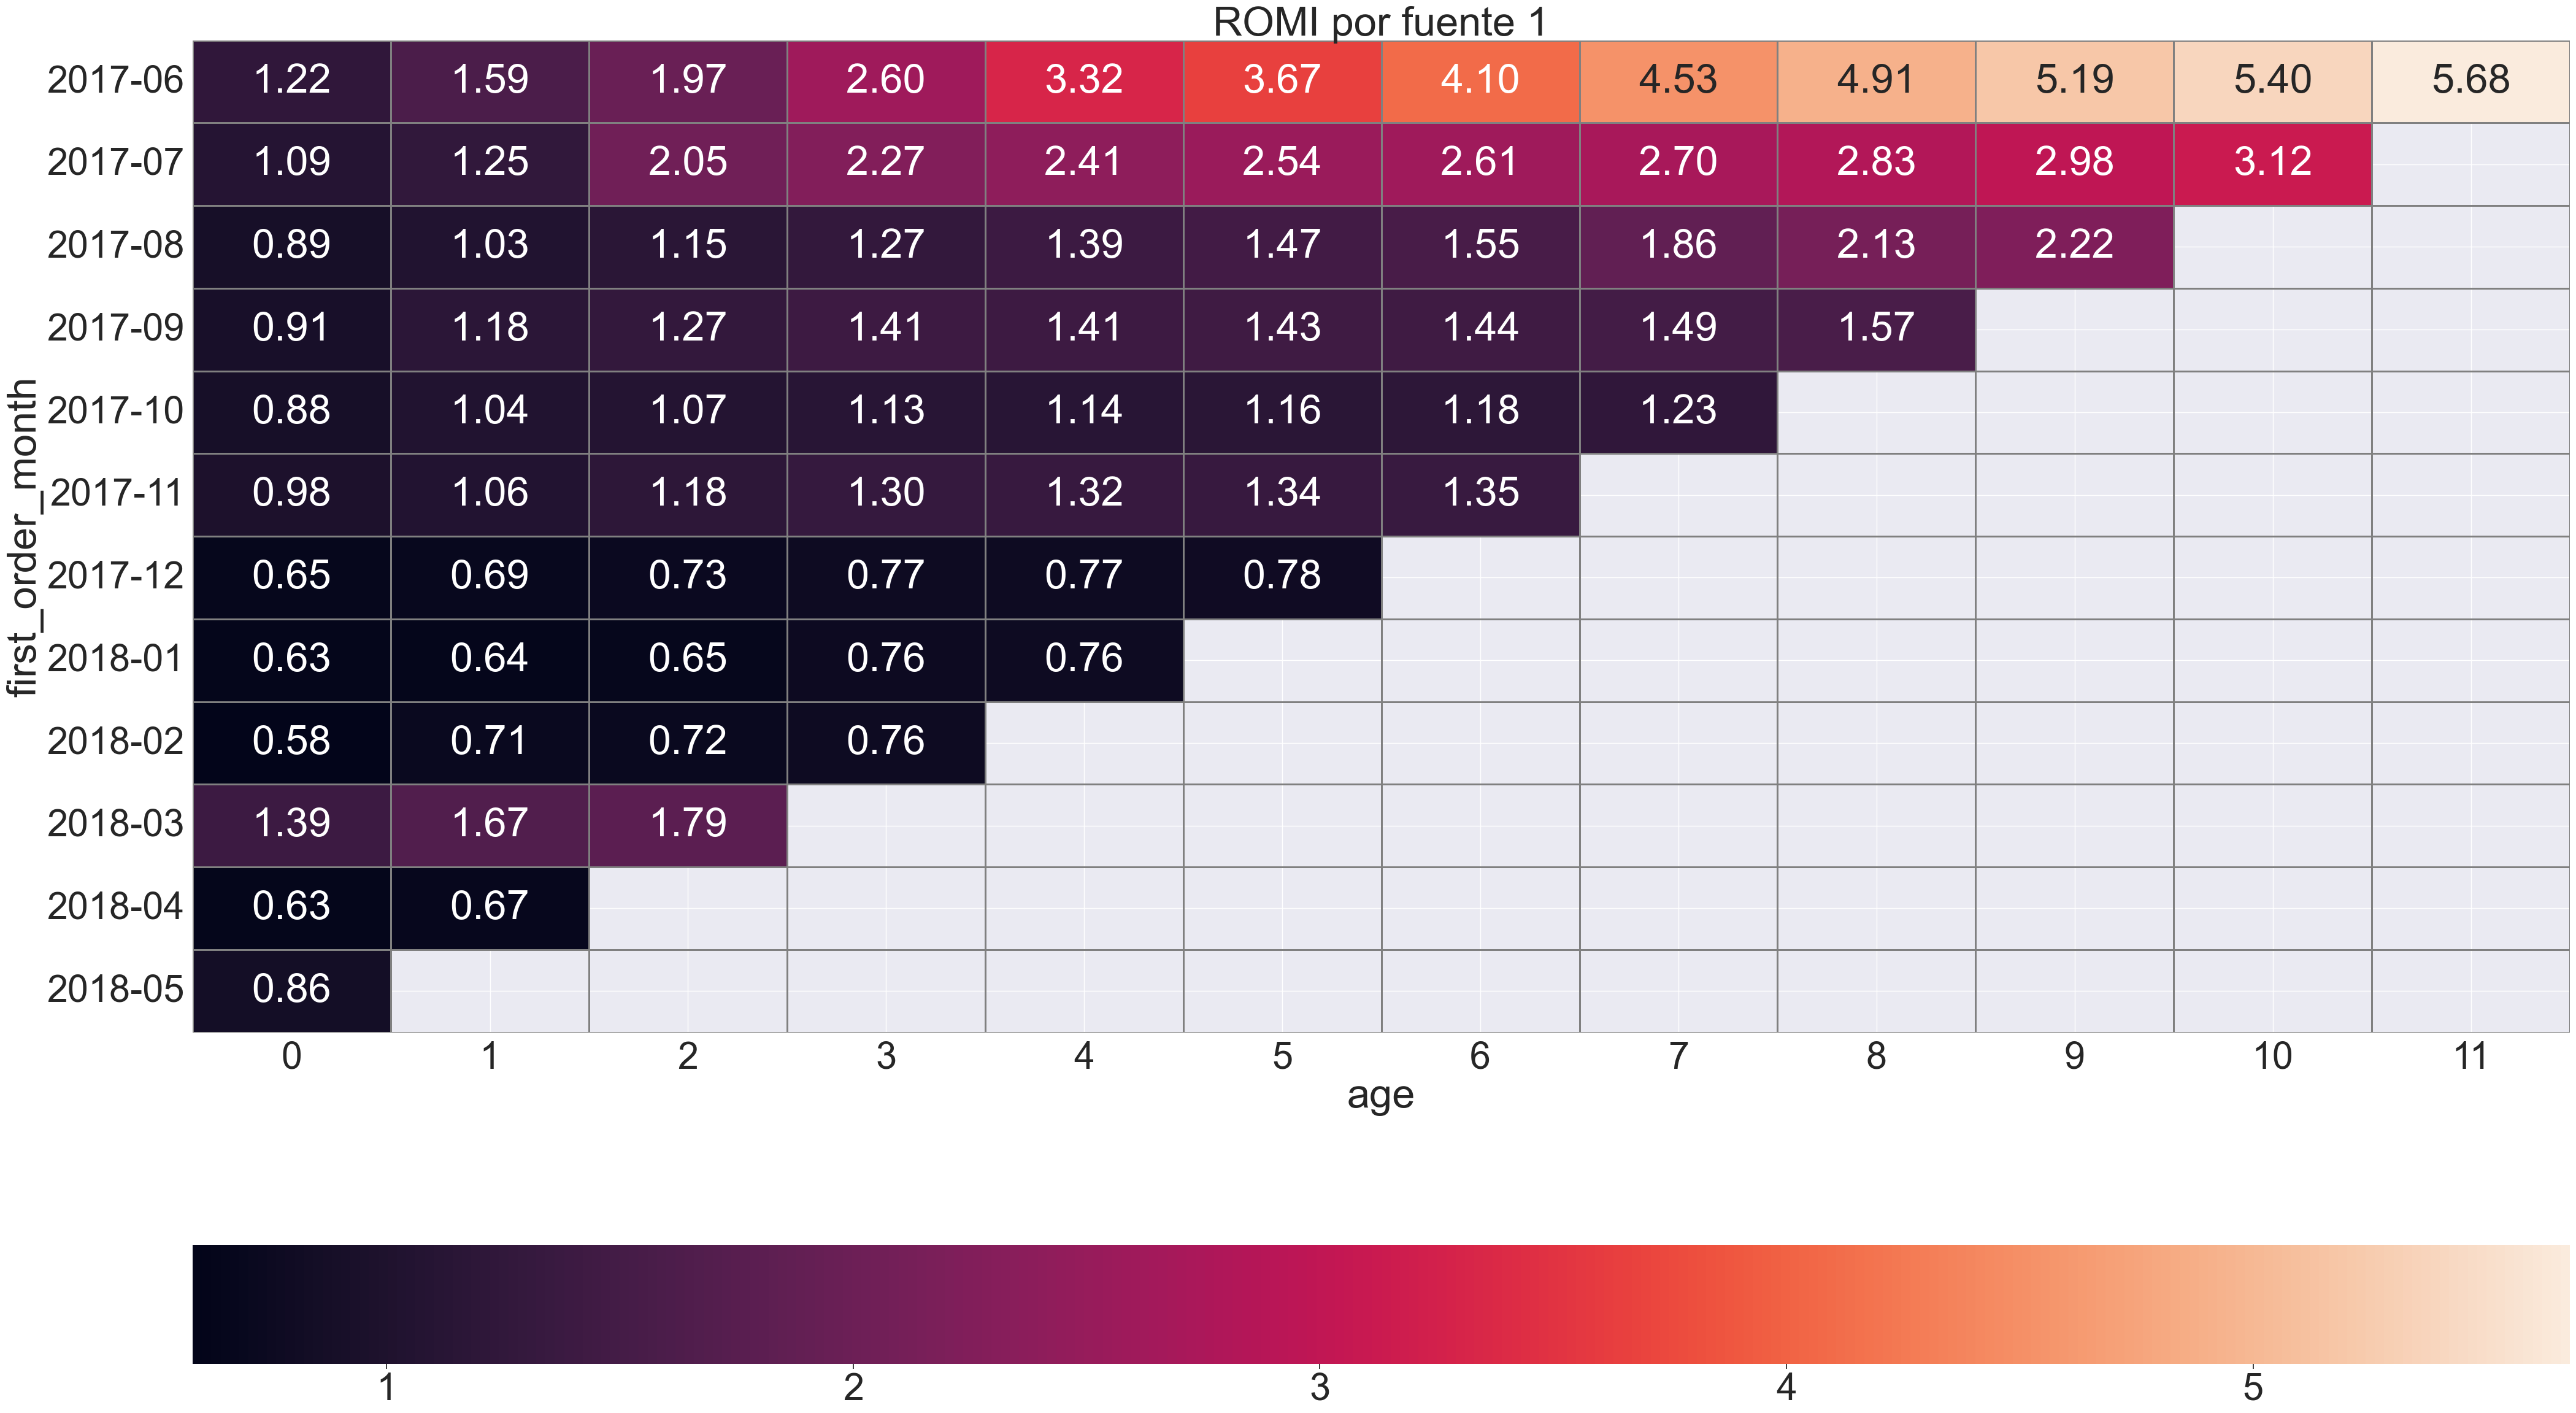

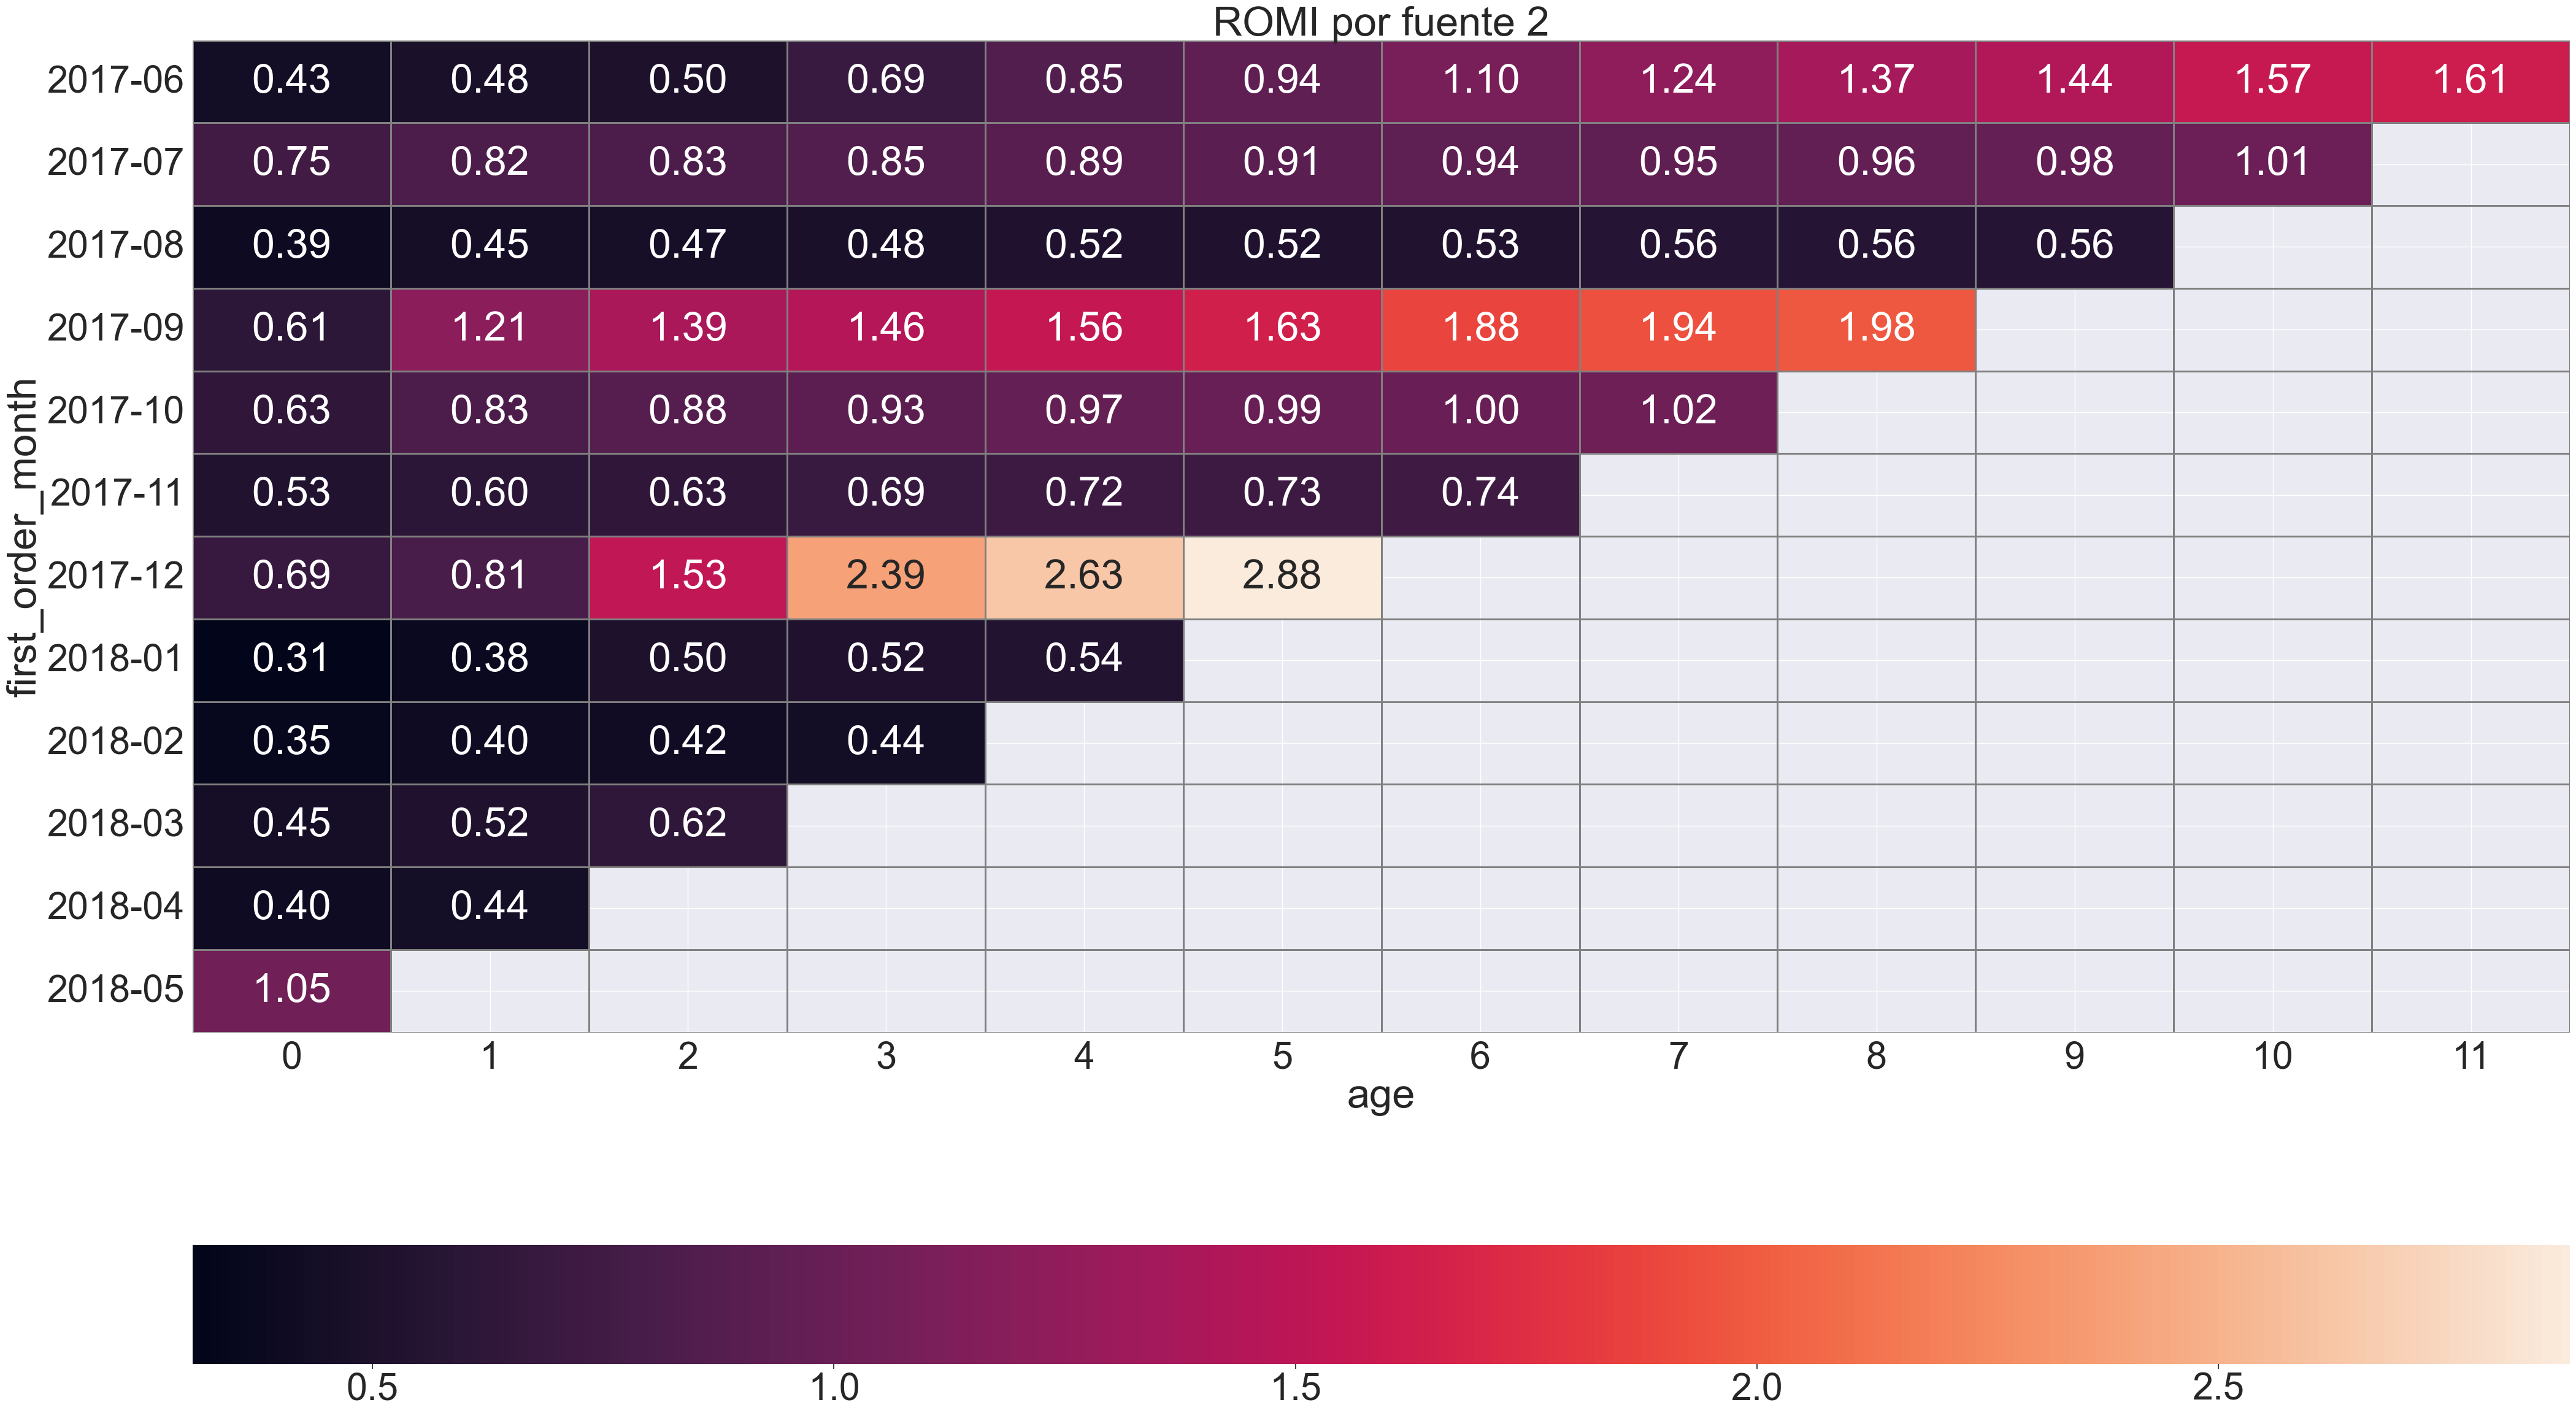

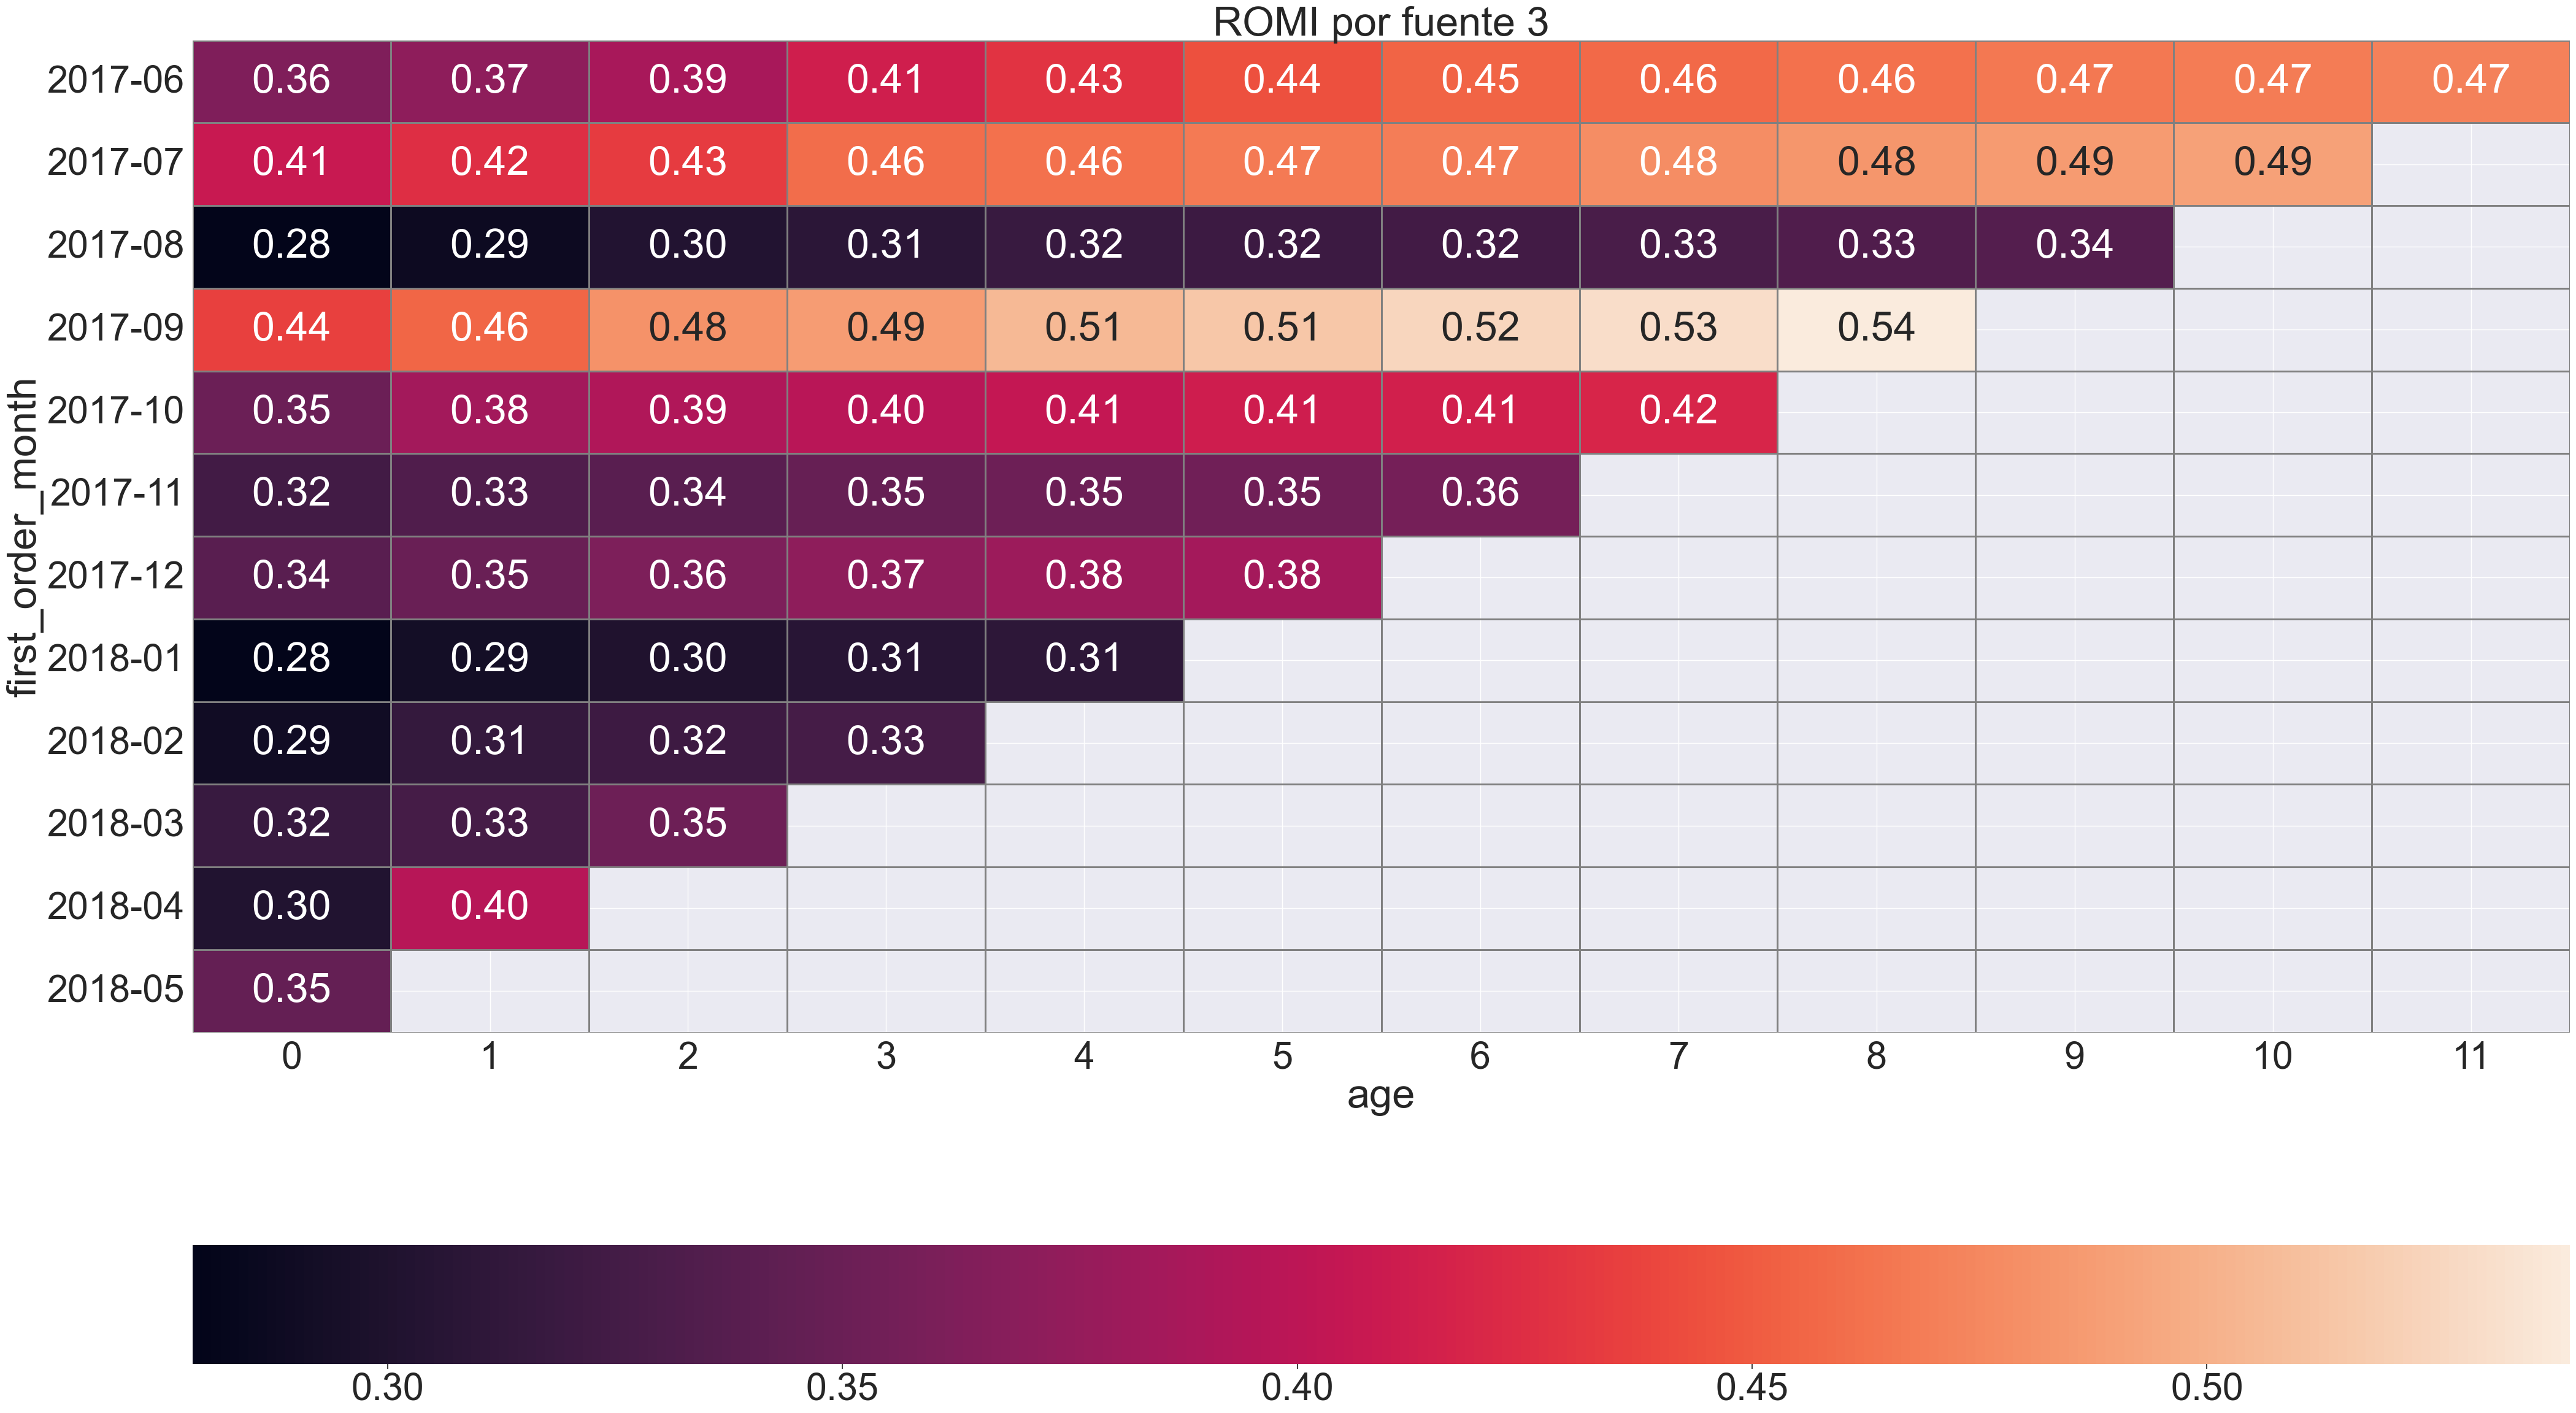

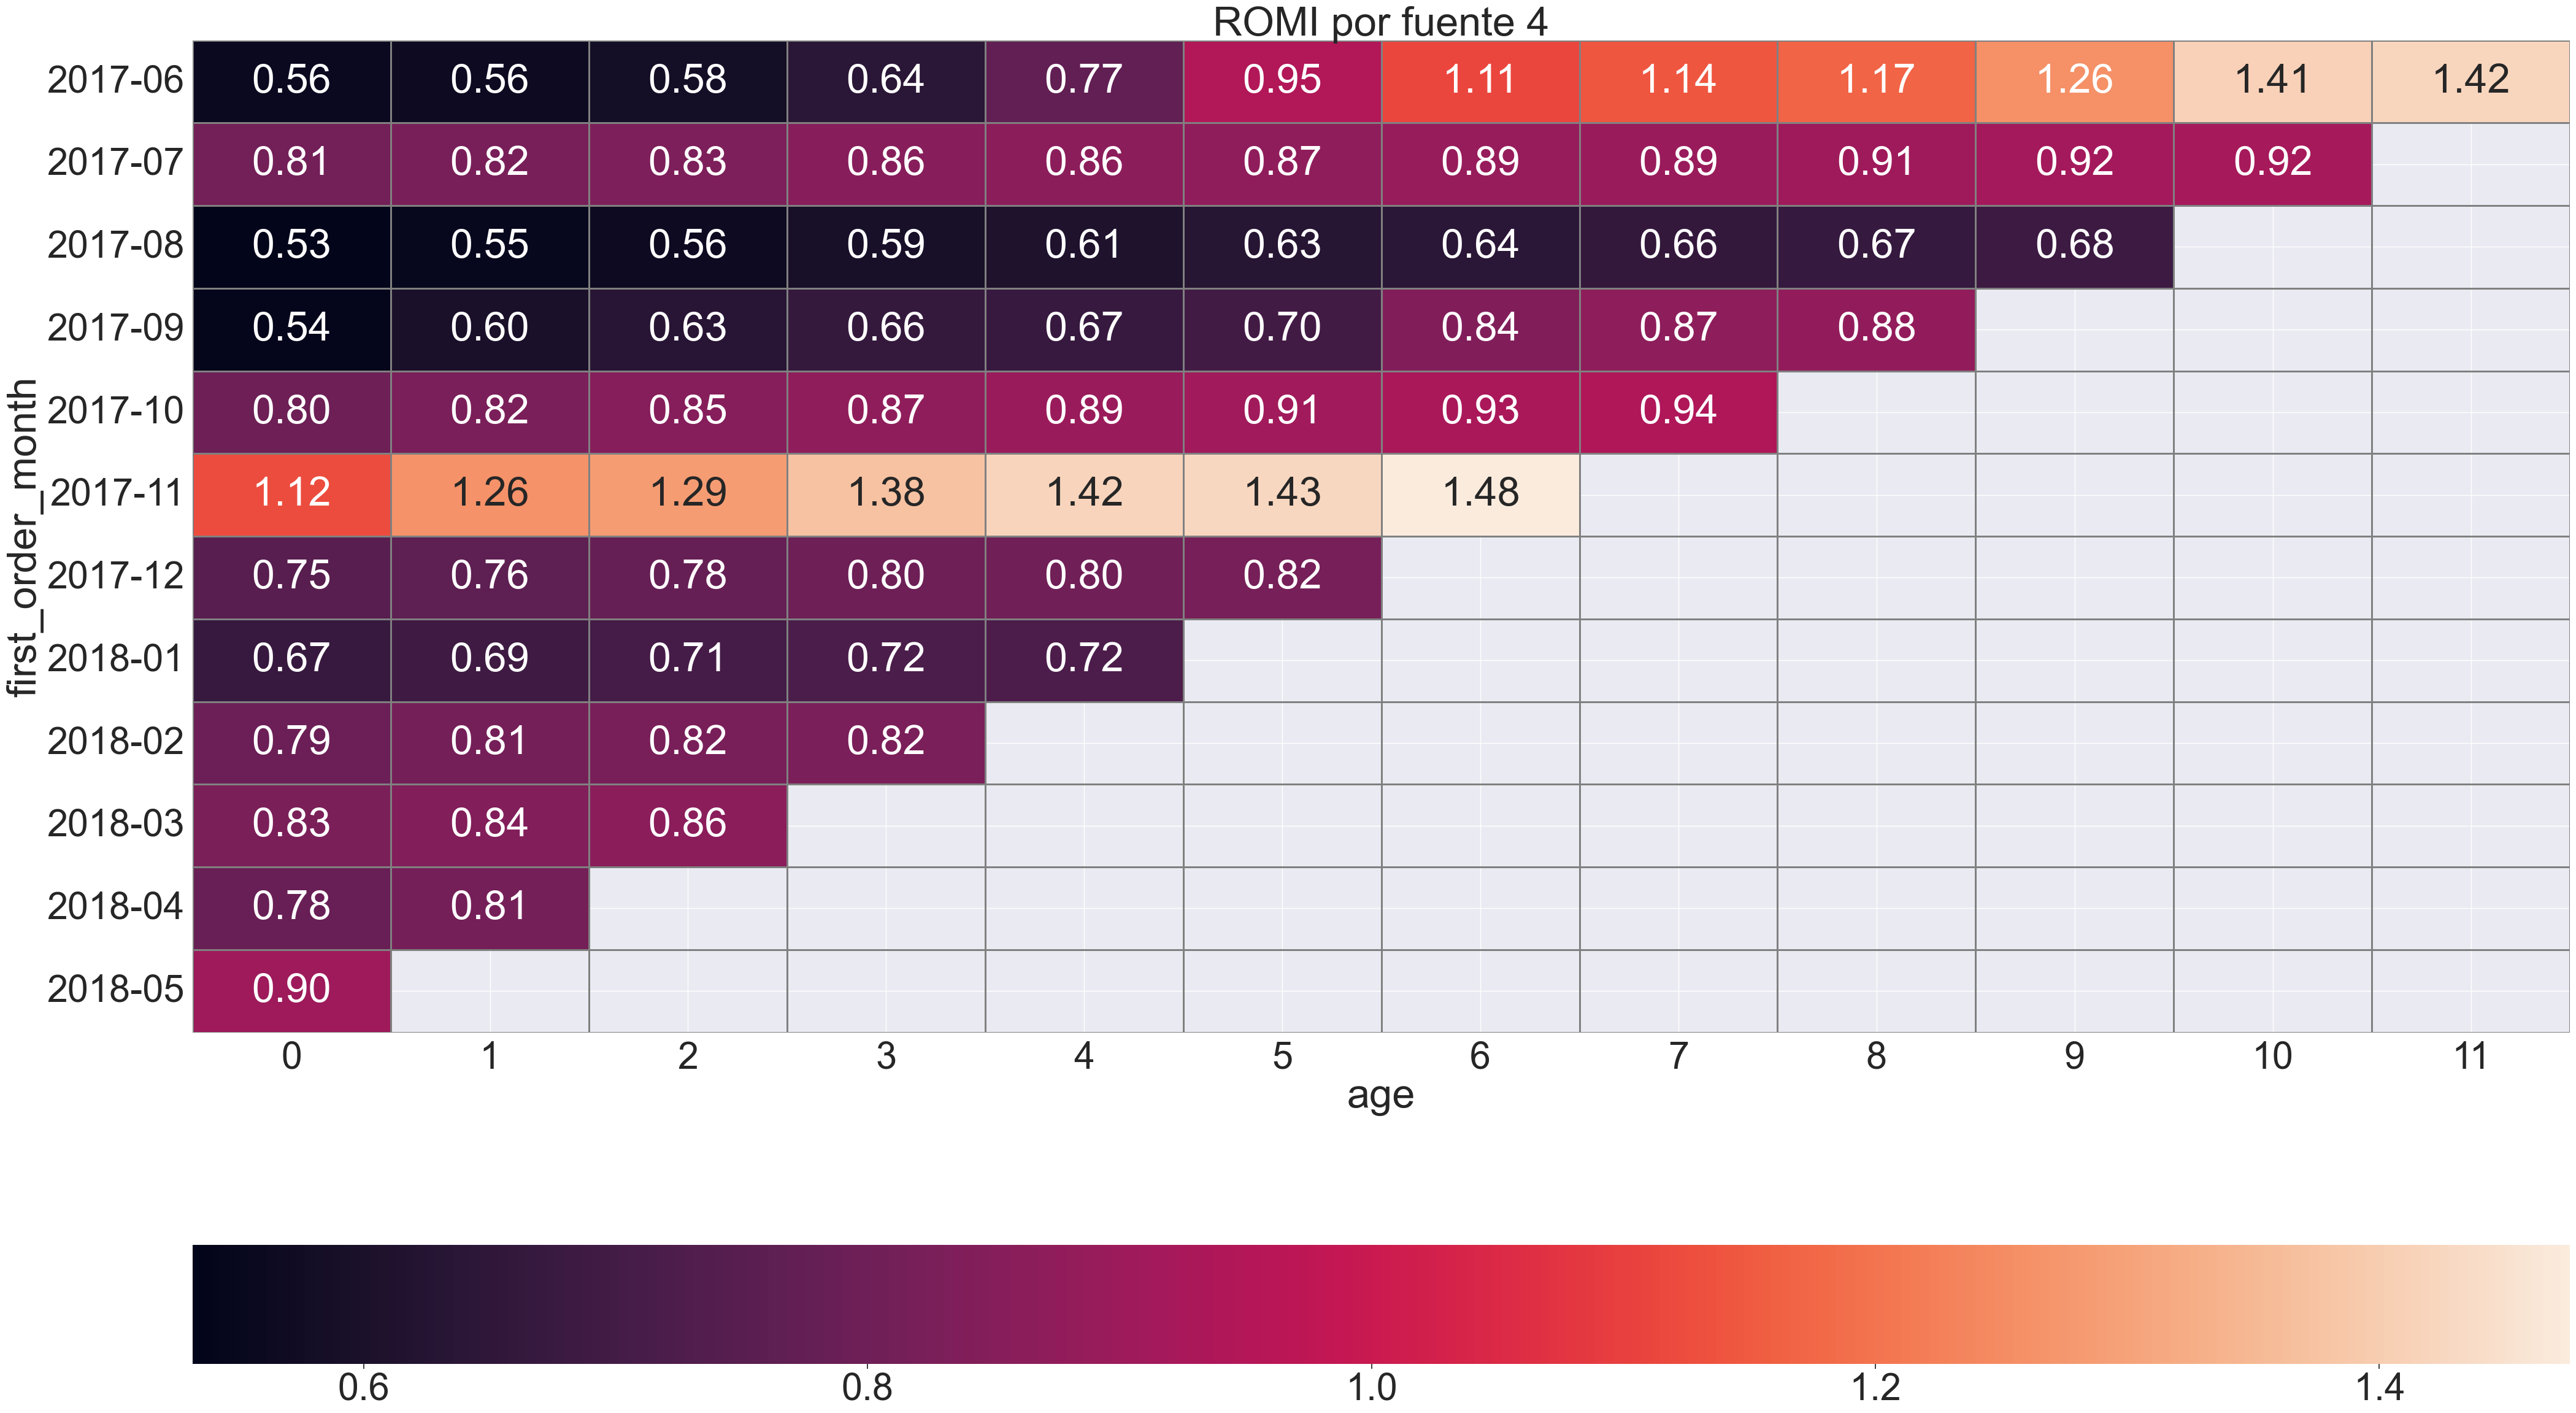

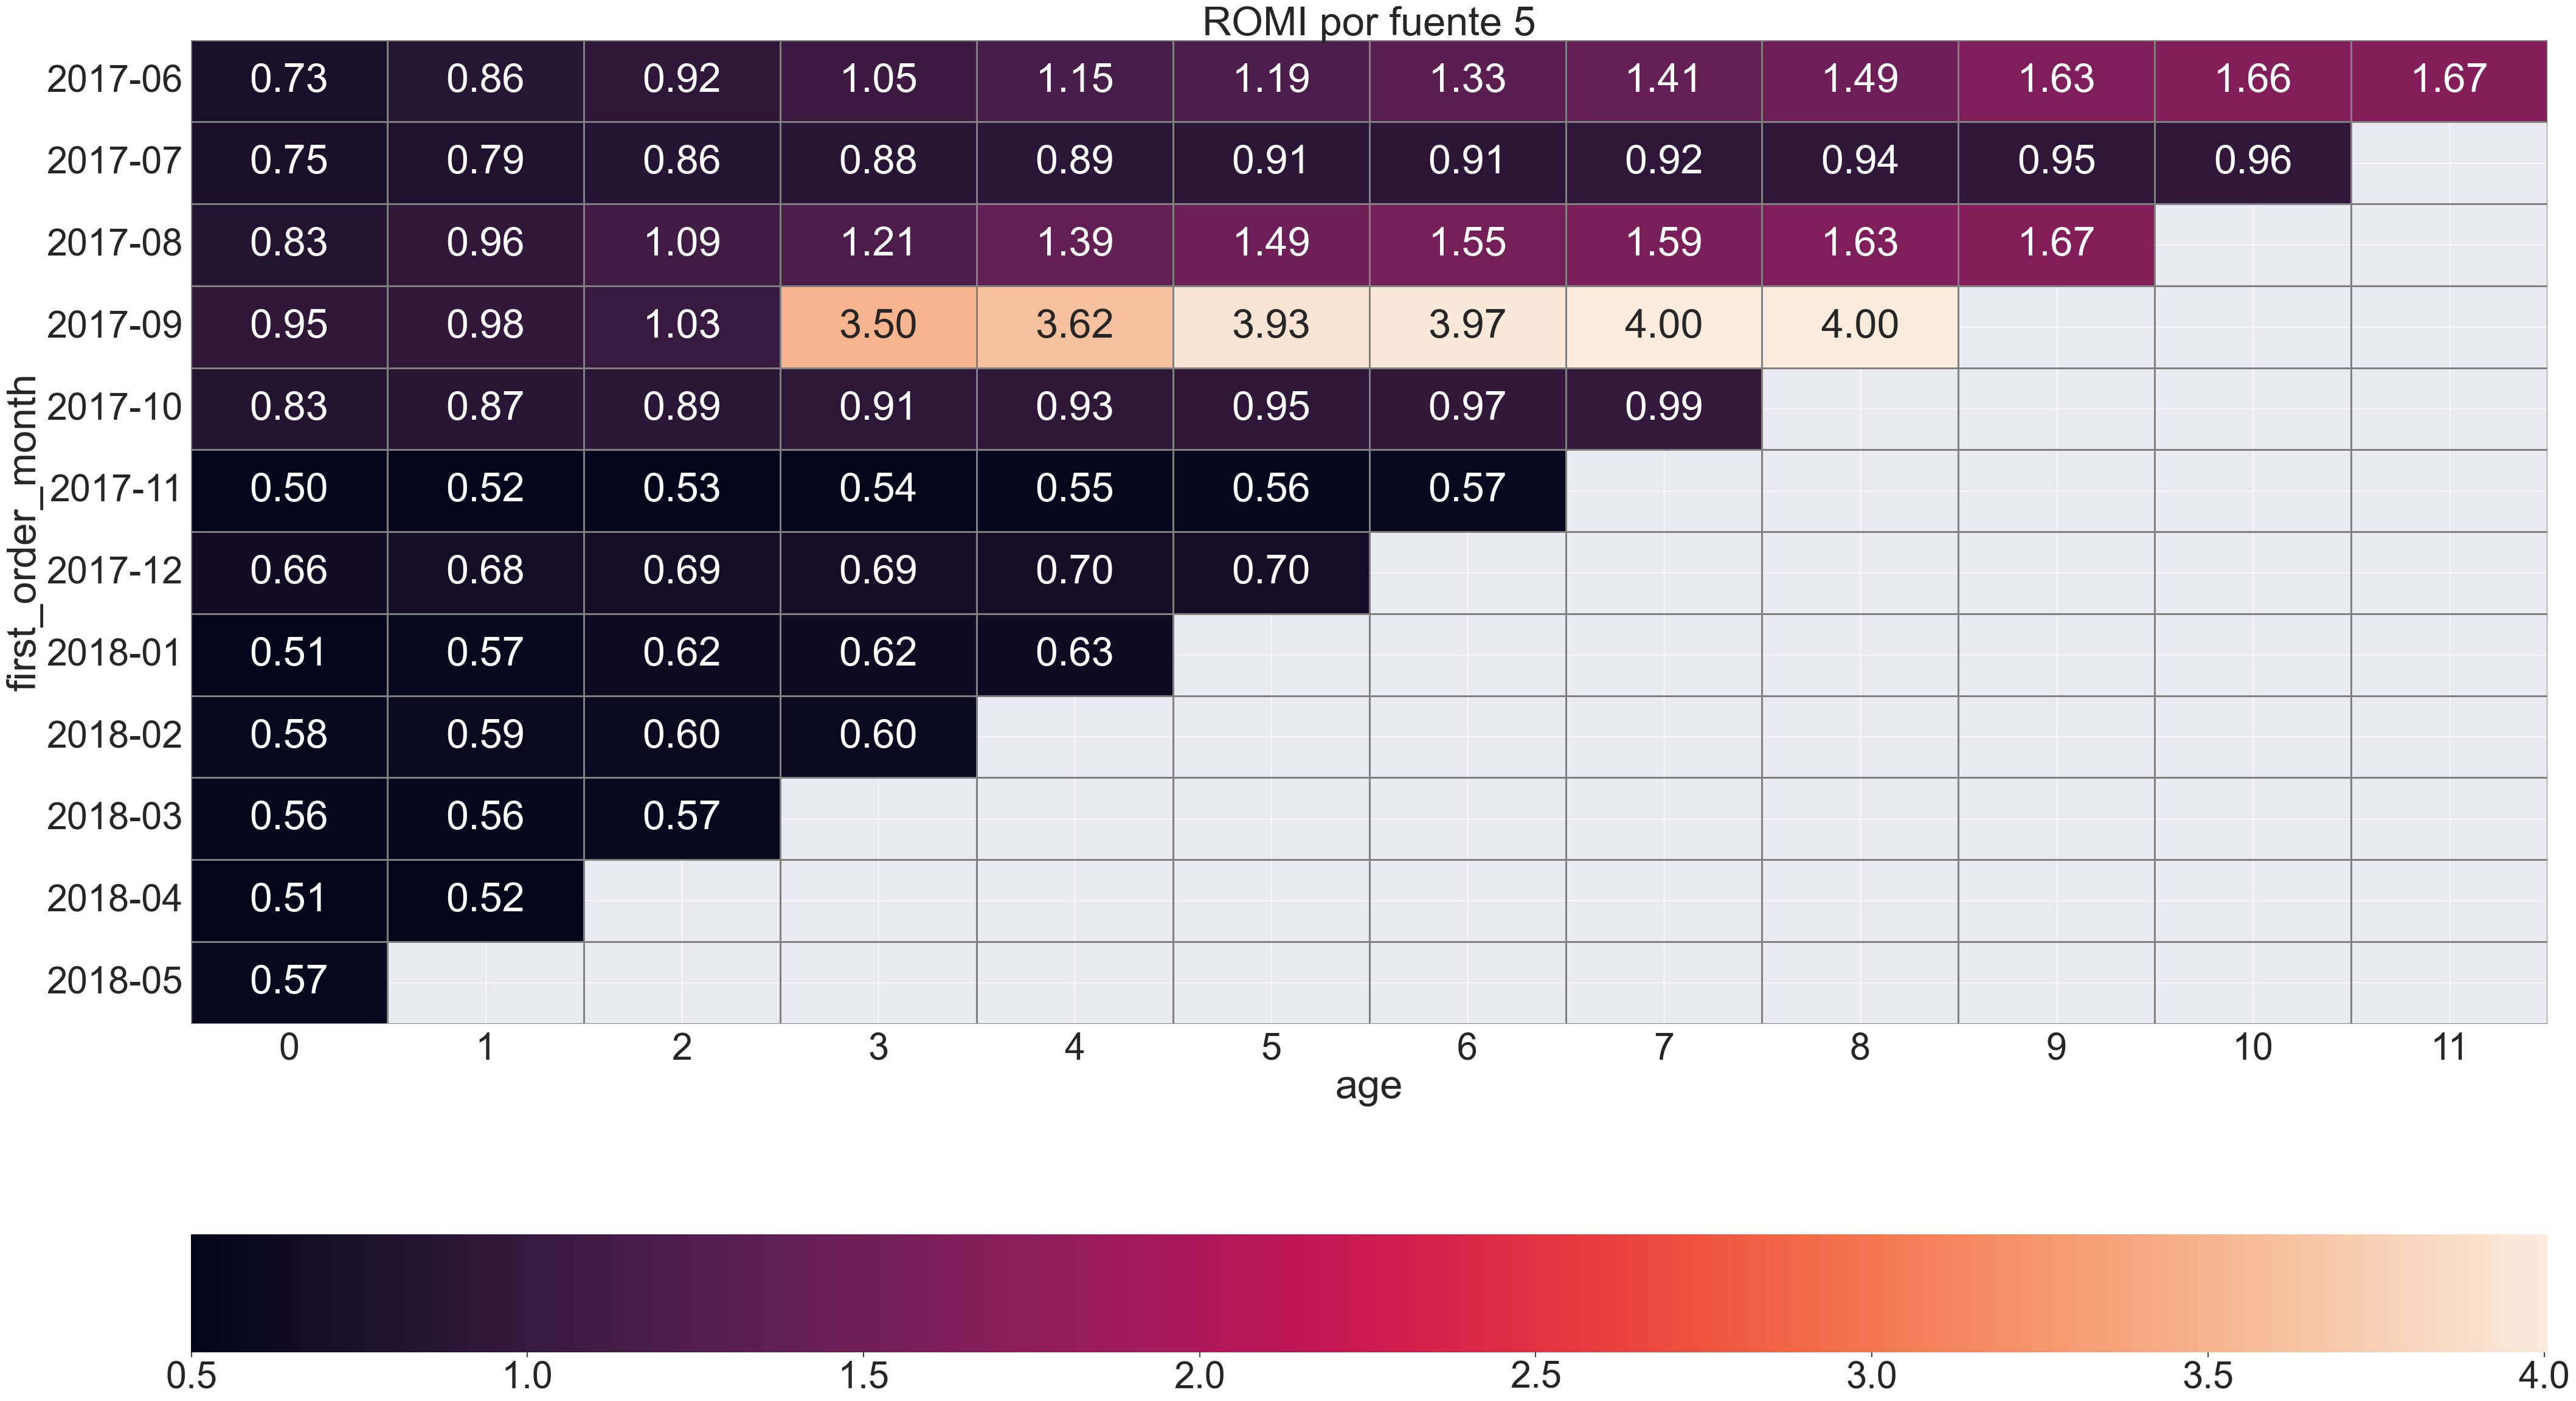

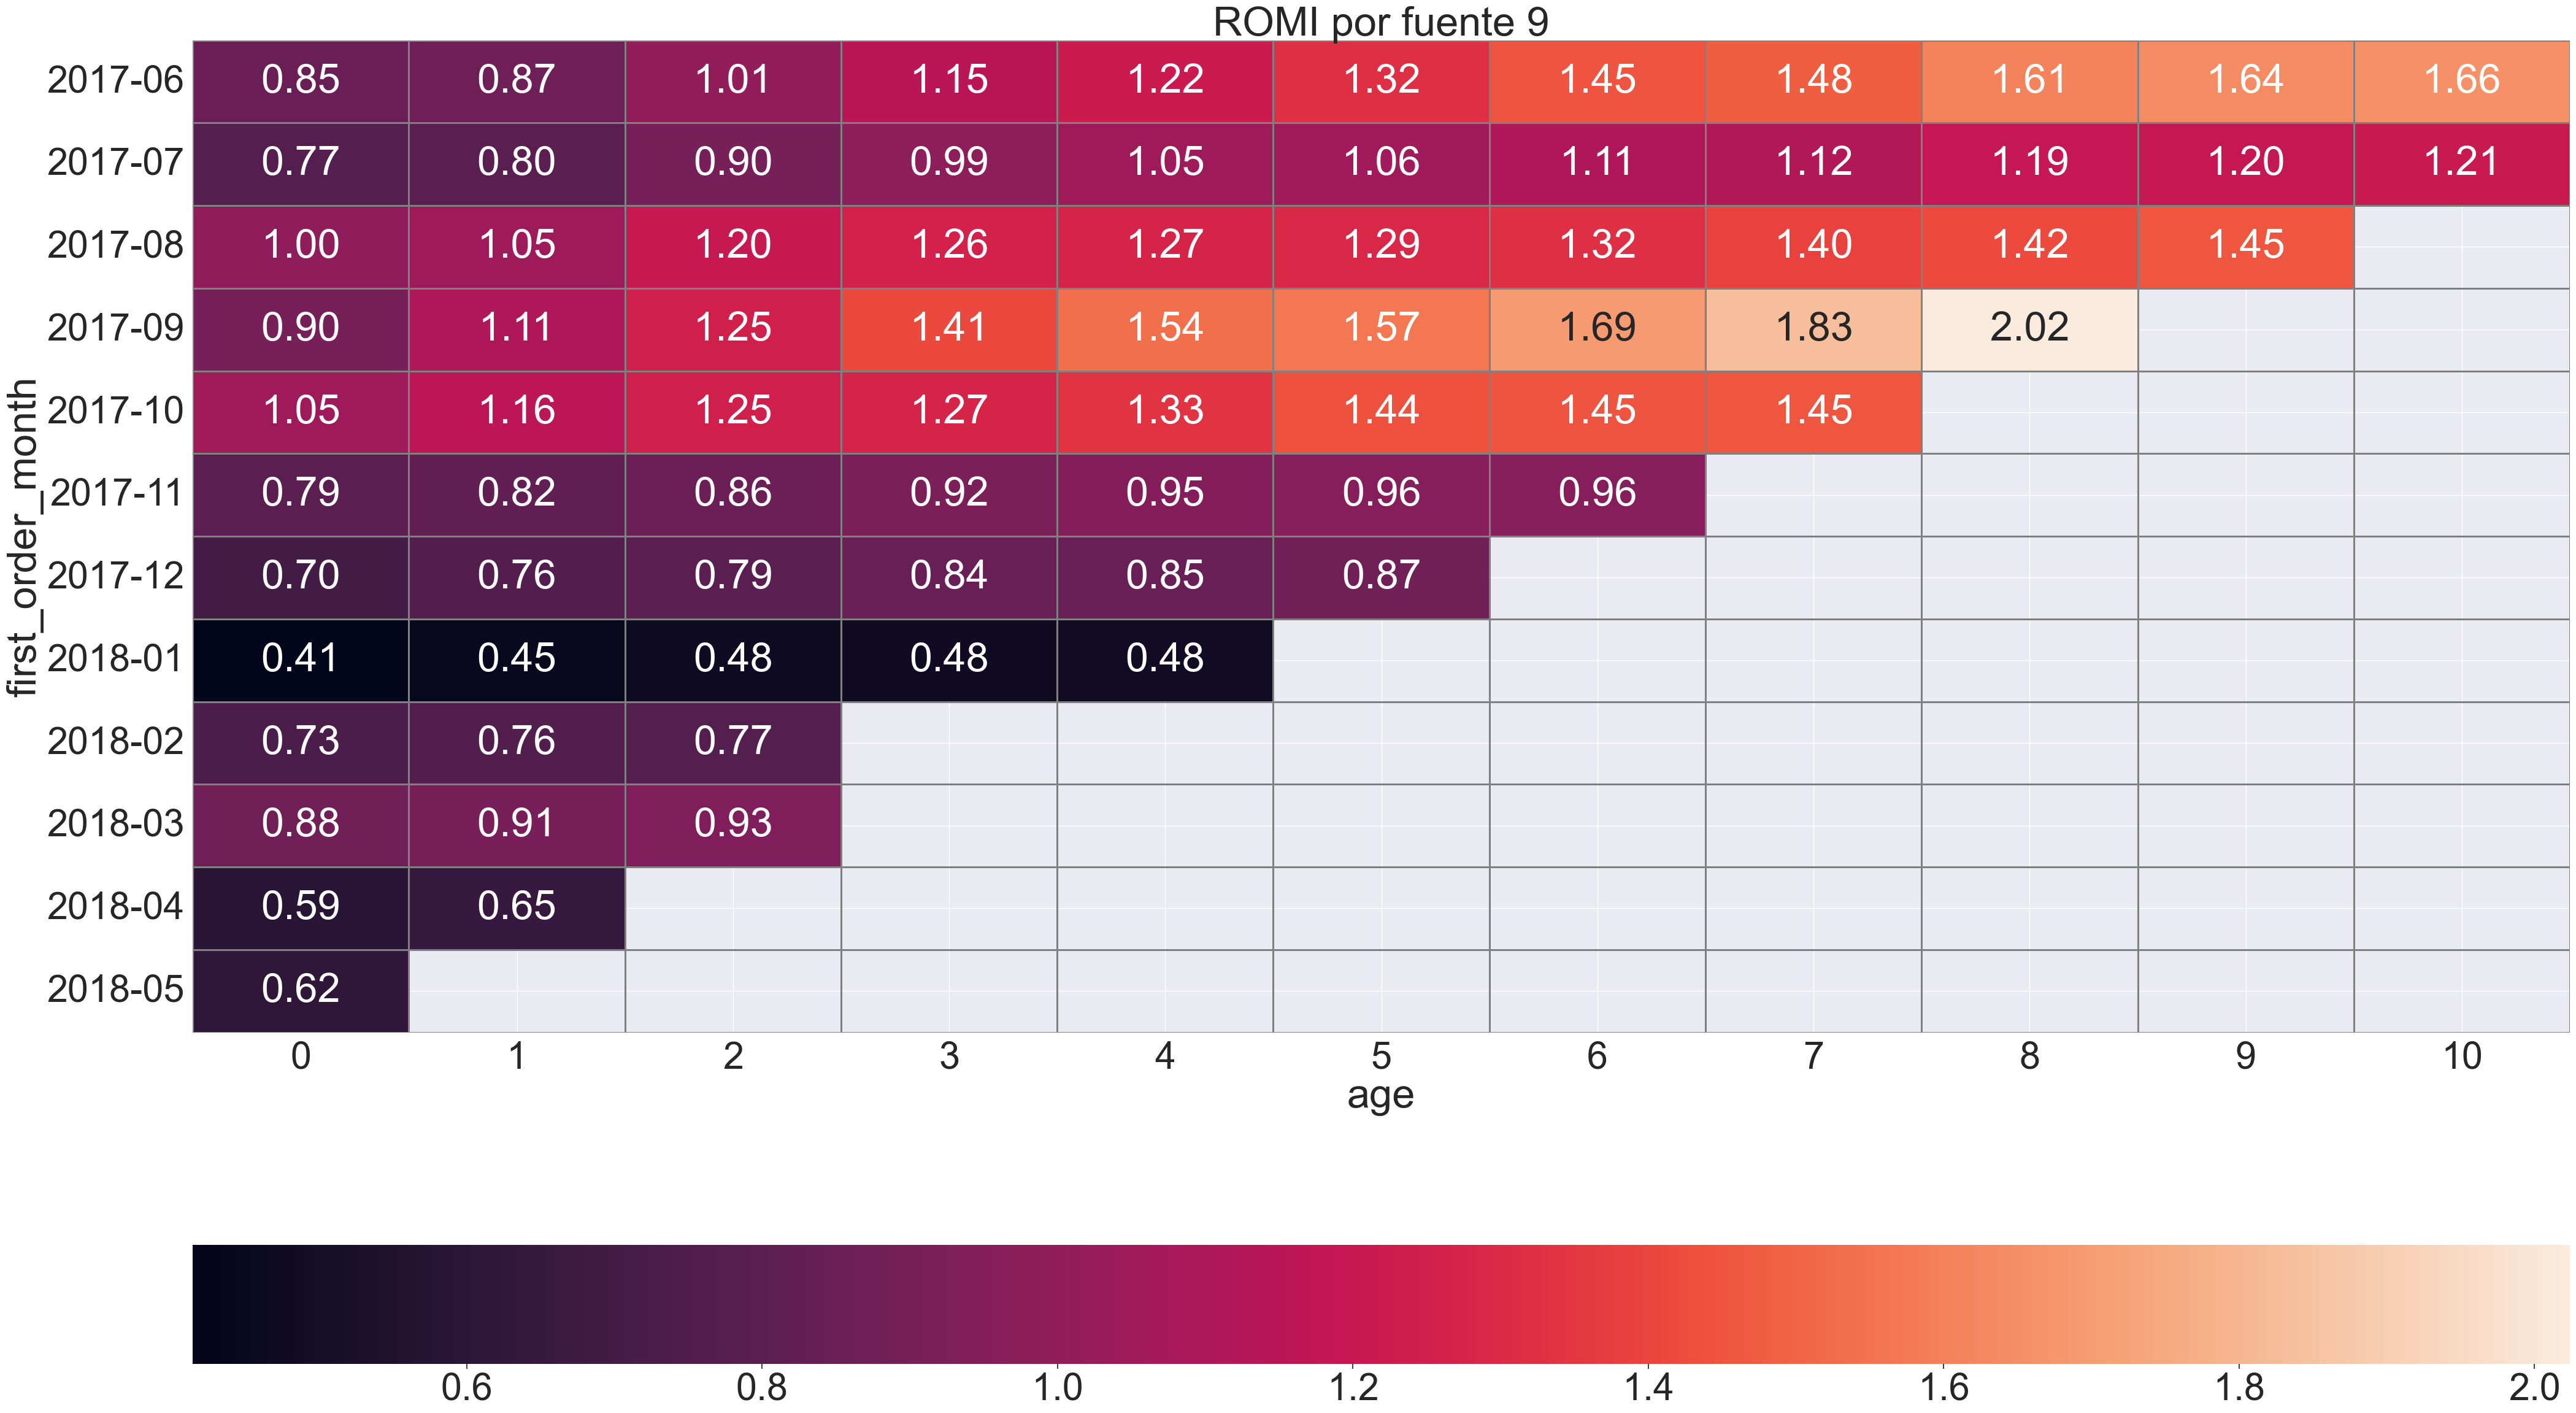

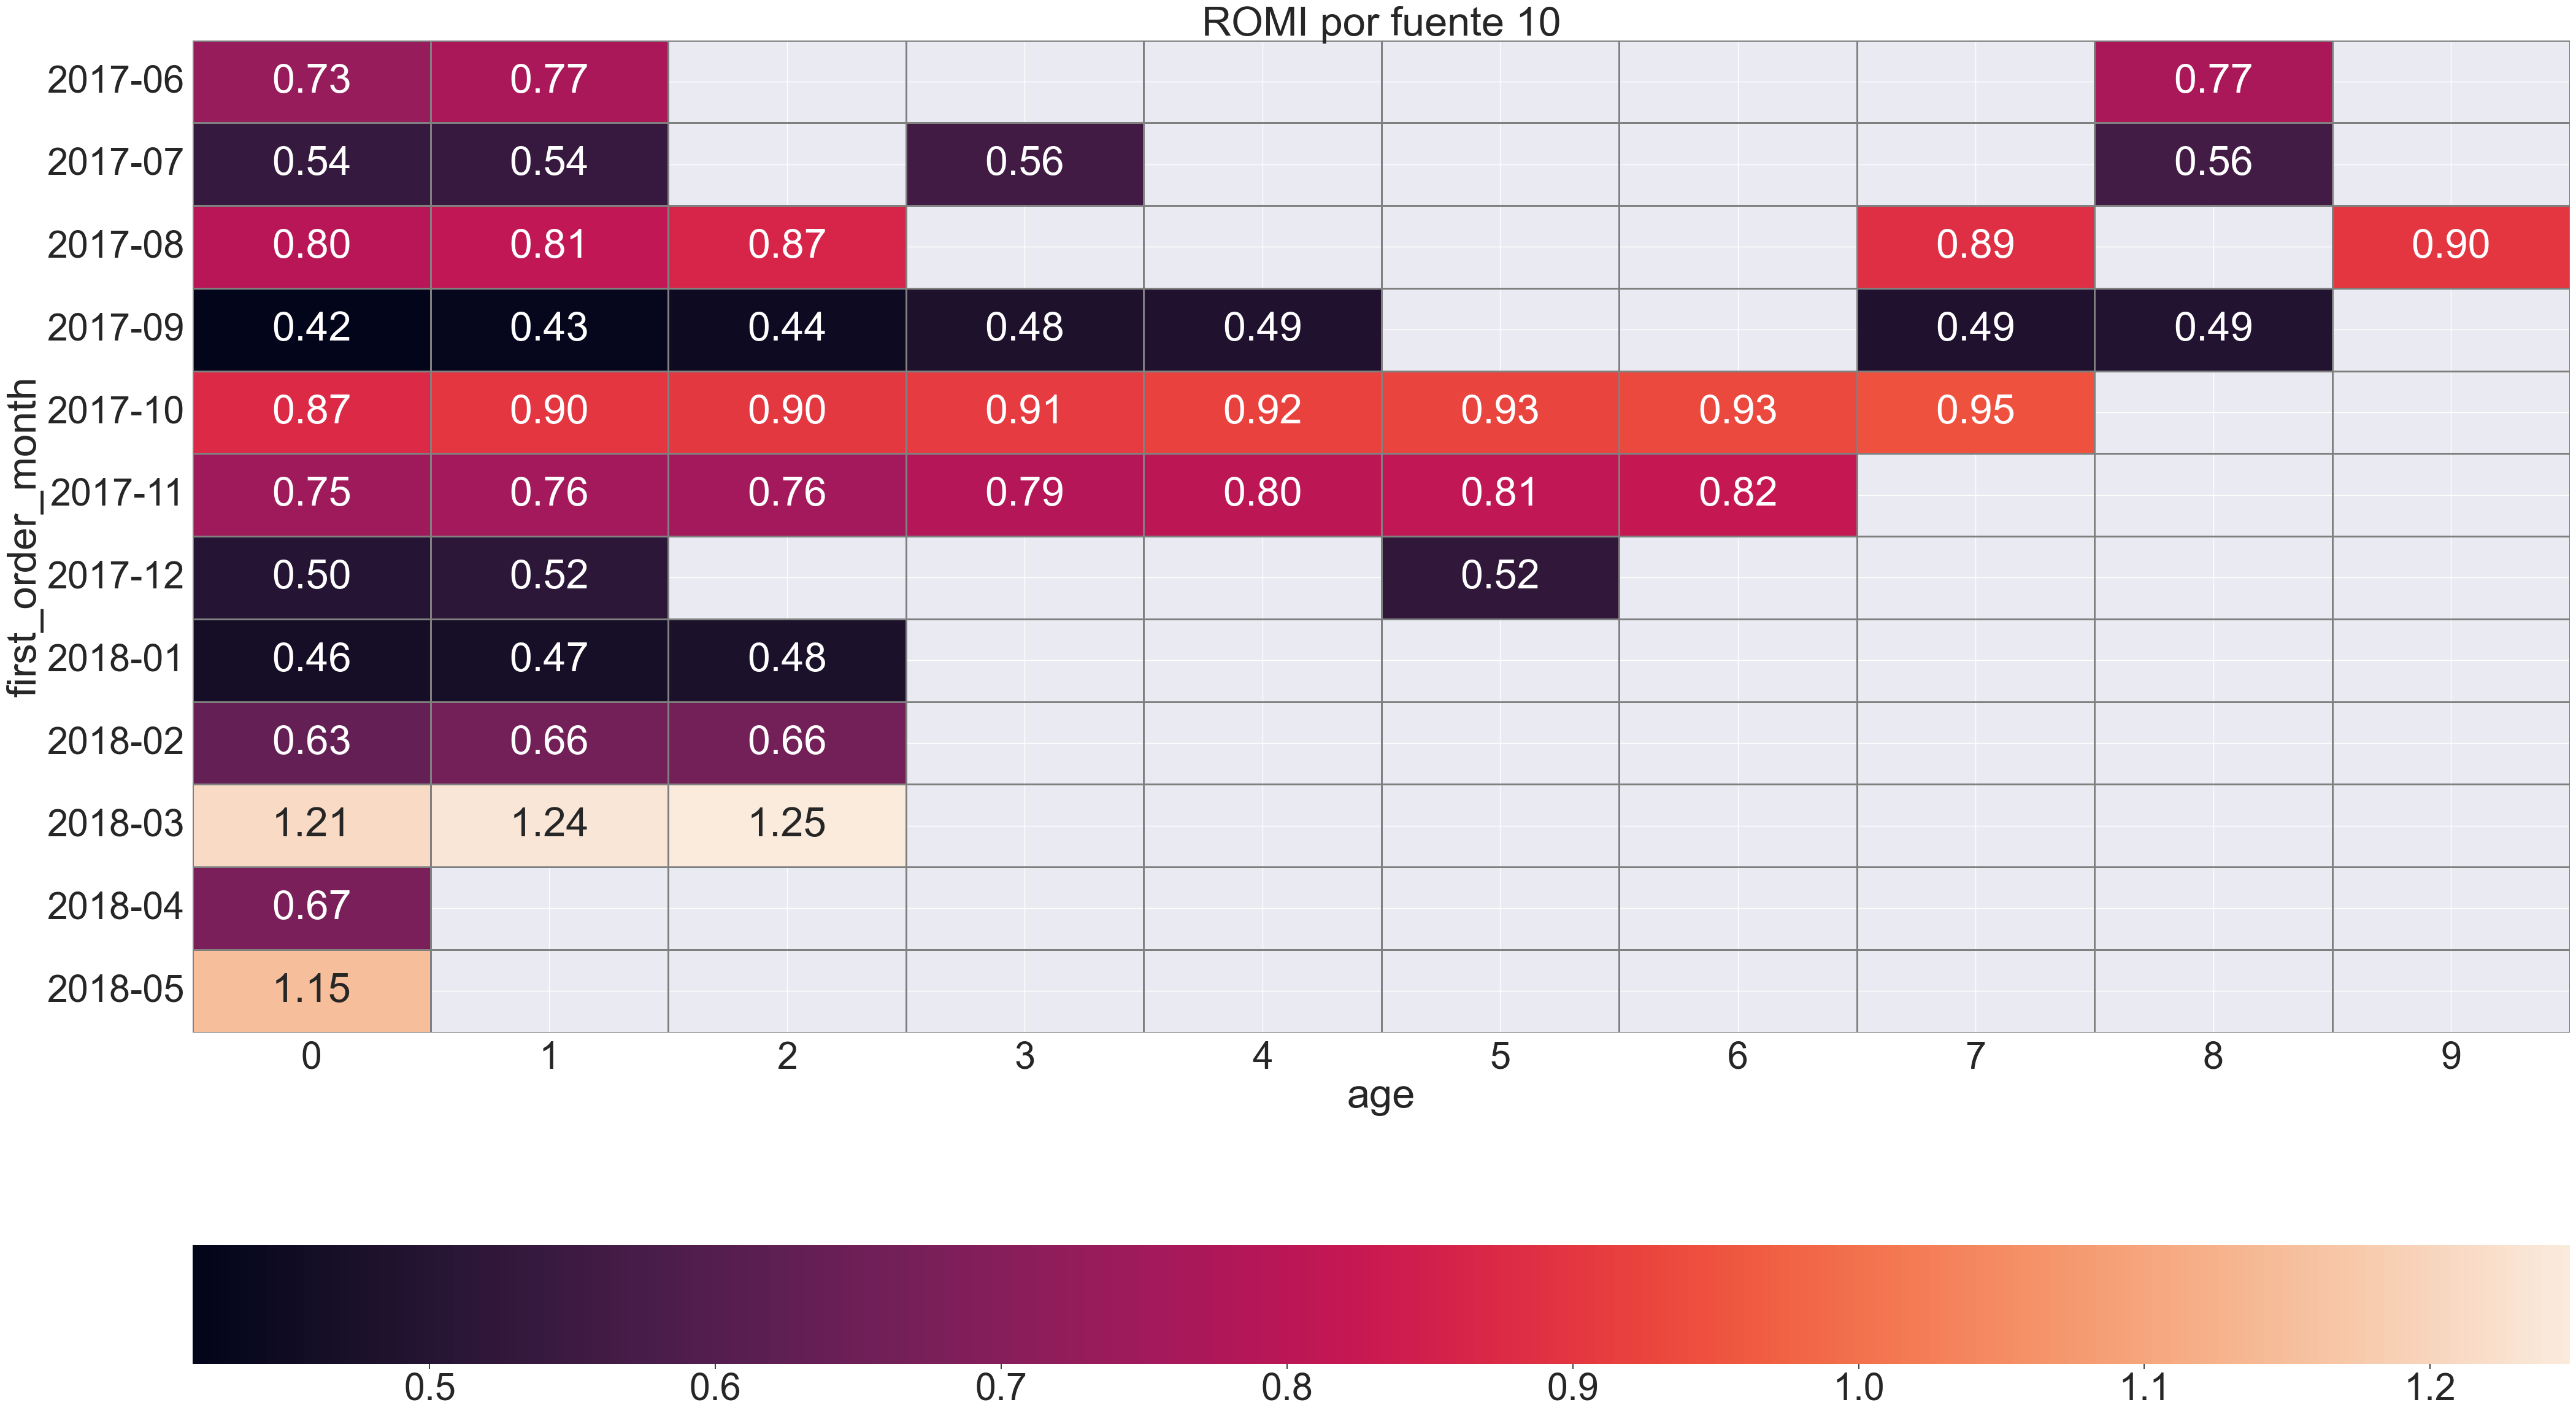

In [59]:
for source, df in buyers.groupby('source_id'):
    if source !=7:

        cohort_sizes_t = (
            df.groupby(['source_id', 'first_order_month'])
            .agg({'uid': 'nunique'})
            .reset_index()
        )
        cohort_sizes_t.columns = ['source_id', 'first_order_month', 'n_buyers']

        cohorts_revenue_t = (
            df.groupby(['source_id', 'first_order_month', 'order_month'])
            .agg({'revenue': 'sum'})
            .reset_index()
        )
        cohorts_revenue_t.columns = ['source_id', 'first_order_month', 'order_month', 'gp']

        report_romi = pd.merge(cohort_sizes_t, cohorts_revenue_t, on=['source_id', 'first_order_month'])
        report_romi['age'] = (report_romi['order_month'] - report_romi['first_order_month']).apply(lambda x: x.n)
        report_romi['age'] = report_romi['age'].round().astype('int')
        report_romi['ltv'] = report_romi['gp'] / report_romi['n_buyers']

        report_romi = pd.merge(report_romi,costs.groupby(['source_id', 'costs_month']).agg({'costs': 'sum'}).reset_index(),
                       left_on=['source_id', 'first_order_month'], right_on=['source_id', 'costs_month'])
        report_romi = report_romi.drop(['costs_month'], axis = 1) 
        report_romi['cac'] = report_romi['costs'] / report_romi['n_buyers']
        report_romi['romi'] = report_romi['ltv'] / report_romi['cac']


        romi = report_romi\
                .pivot_table(index='first_order_month', columns='age', values='romi', aggfunc='mean')\
                .cumsum(axis=1)
        romi.round(2).fillna('')

        
        romi.index=romi.index.astype(str)
        sns.heatmap(romi, annot=True, fmt='.2f', linewidths=1, linecolor='grey', cbar_kws= {'orientation': 'horizontal'} 
            ).set(title ='ROMI por fuente {}'.format(source))
        plt.show()